In [30]:
import pandas as pd

orders_df = pd.read_excel("orders.xlsx")
orders_df.head()

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Address Blocked (Sold-To),Requirement Segment,Address Blocked (Partner),Employee ID,Action Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,NaN,NaN,NaN,NaN,NaN,ZRN1,300,300.0,Danushka Bandara,0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,NaN,NaN,NaN,NaN,NaN,ZRN1,15,15.0,Danushka Bandara,0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,NaN,NaN,NaN,NaN,NaN,ZRN1,20,20.0,Danushka Bandara,0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,NaN,NaN,NaN,NaN,NaN,ZRN1,10,10.0,Danushka Bandara,0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,NaN,NaN,NaN,NaN,NaN,ZRN1,1,1.0,Danushka Bandara,0


In [4]:
# Convert date columns to datetime (errors='coerce' will turn invalid dates into NaT)
orders_df['Created On'] = pd.to_datetime(orders_df['Created On'], errors='coerce')
orders_df['Goods Issue Date'] = pd.to_datetime(orders_df['Goods Issue Date'], errors='coerce')

# Calculate Lead Time (in days)
orders_df['Lead Time'] = (orders_df['Goods Issue Date'] - orders_df['Created On']).dt.days

# Ensure quantity columns are numeric
orders_df['Order Quantity (Item)'] = pd.to_numeric(orders_df['Order Quantity (Item)'], errors='coerce')
orders_df['Confirmed Quantity (Item)'] = pd.to_numeric(orders_df['Confirmed Quantity (Item)'], errors='coerce')

# Calculate Lost Qty
orders_df['Lost Qty'] = orders_df['Order Quantity (Item)'] - orders_df['Confirmed Quantity (Item)']

In [5]:
orders_df.head(10)

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Address Blocked (Partner),Employee ID,Action Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity,Lead Time,Lost Qty
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,NaN,NaN,NaN,ZRN1,300,300.0,Danushka Bandara,0,0.0,0.0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,NaN,NaN,NaN,ZRN1,15,15.0,Danushka Bandara,0,0.0,0.0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,NaN,NaN,NaN,ZRN1,20,20.0,Danushka Bandara,0,0.0,0.0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,NaN,NaN,NaN,ZRN1,10,10.0,Danushka Bandara,0,0.0,0.0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,NaN,NaN,NaN,ZRN1,1,1.0,Danushka Bandara,0,0.0,0.0
5,900273244 - Return,2025-11-27,ZRE,60012031,60,119237,B3424689,12,EA,190296.61,...,NaN,NaN,NaN,ZRN1,12,12.0,Aseni Savinya,0,0.0,0.0
6,900273244 - Return,2025-11-27,ZRE,60012031,70,119237,B3431613,48,EA,78459.66,...,NaN,NaN,NaN,ZRN1,48,48.0,Aseni Savinya,0,0.0,0.0
7,900273244 - Return,2025-11-27,ZRE,60012031,80,119237,B87520219,34,EA,57189.15,...,NaN,NaN,NaN,ZRN1,34,34.0,Aseni Savinya,0,0.0,0.0
8,900247770 - Return,2025-11-27,ZRE,60012030,110,119237,B3375771,3,EA,7102.37,...,NaN,NaN,NaN,ZRN1,3,3.0,Aseni Savinya,0,0.0,0.0
9,900241197 - Return,2025-11-27,ZRE,60012029,50,119237,B71391919N,1,EA,295652.33,...,NaN,NaN,NaN,ZRN1,1,1.0,Aseni Savinya,0,0.0,0.0


In [6]:
empty_cols = orders_df.columns[orders_df.isnull().all()]
print("Columns with all null values:", empty_cols)

Columns with all null values: Index(['Billing Block', 'Sales Document Description', 'Exchange Rate Type',
       'Delivery Block', 'Batch', 'Personnel Partner Function',
       'Partner Function', 'Address Number', 'Partner', 'Partner Name',
       'Unit Validity Period', 'Val.Period.Category', 'Installation Date',
       'Acceptance Date', 'Contract Signed', 'Contract Start Date',
       'Contract End Date', 'Cancellation Proced.', 'Action',
       'Receipt of Canc.', 'Req.Cancellat.Date', 'Cancellation Party',
       'Reason for Cancel.', 'Cancel.Doc.for Part.', 'Date of Canc.Doc.',
       'Dismantling Date', 'Action Date', 'Delivery Block Description',
       'Billing Block Description', 'Personnel Name',
       'Address Blocked (Sold-To)', 'Requirement Segment',
       'Address Blocked (Partner)', 'Employee ID', 'Action Description'],
      dtype='object')


In [7]:
orders_df.drop(columns=empty_cols, inplace=True)

In [8]:
orders_df.head(10)

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Distribution Channel Name,Division Name,Sales Document Type Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity,Lead Time,Lost Qty
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,Parts sales,Common,Sales Return,ZRN1,300,300.0,Danushka Bandara,0,0.0,0.0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,Parts sales,Common,Sales Return,ZRN1,15,15.0,Danushka Bandara,0,0.0,0.0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,Parts sales,Common,Sales Return,ZRN1,20,20.0,Danushka Bandara,0,0.0,0.0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,Parts sales,Common,Sales Return,ZRN1,10,10.0,Danushka Bandara,0,0.0,0.0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,Parts sales,Common,Sales Return,ZRN1,1,1.0,Danushka Bandara,0,0.0,0.0
5,900273244 - Return,2025-11-27,ZRE,60012031,60,119237,B3424689,12,EA,190296.61,...,Parts sales,Lubricant,Sales Return,ZRN1,12,12.0,Aseni Savinya,0,0.0,0.0
6,900273244 - Return,2025-11-27,ZRE,60012031,70,119237,B3431613,48,EA,78459.66,...,Parts sales,Lubricant,Sales Return,ZRN1,48,48.0,Aseni Savinya,0,0.0,0.0
7,900273244 - Return,2025-11-27,ZRE,60012031,80,119237,B87520219,34,EA,57189.15,...,Parts sales,Lubricant,Sales Return,ZRN1,34,34.0,Aseni Savinya,0,0.0,0.0
8,900247770 - Return,2025-11-27,ZRE,60012030,110,119237,B3375771,3,EA,7102.37,...,Parts sales,Lubricant,Sales Return,ZRN1,3,3.0,Aseni Savinya,0,0.0,0.0
9,900241197 - Return,2025-11-27,ZRE,60012029,50,119237,B71391919N,1,EA,295652.33,...,Parts sales,Lubricant,Sales Return,ZRN1,1,1.0,Aseni Savinya,0,0.0,0.0


Lead Time Statistics (days)
count    52452.000000
mean         3.360406
std         14.059622
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        348.000000
Name: Lead Time, dtype: float64


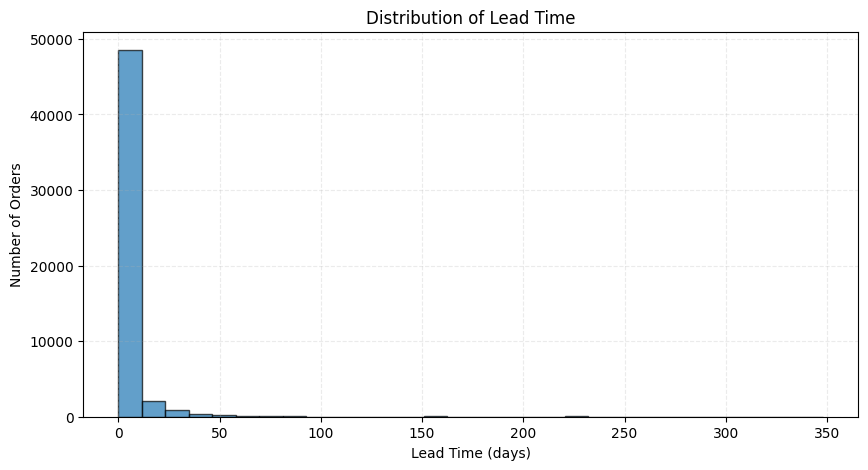

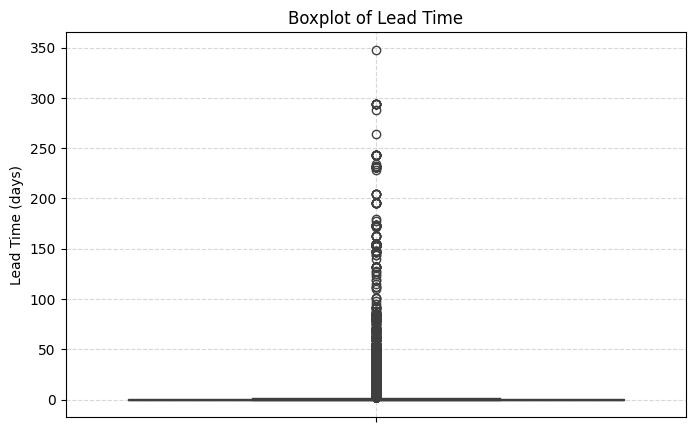

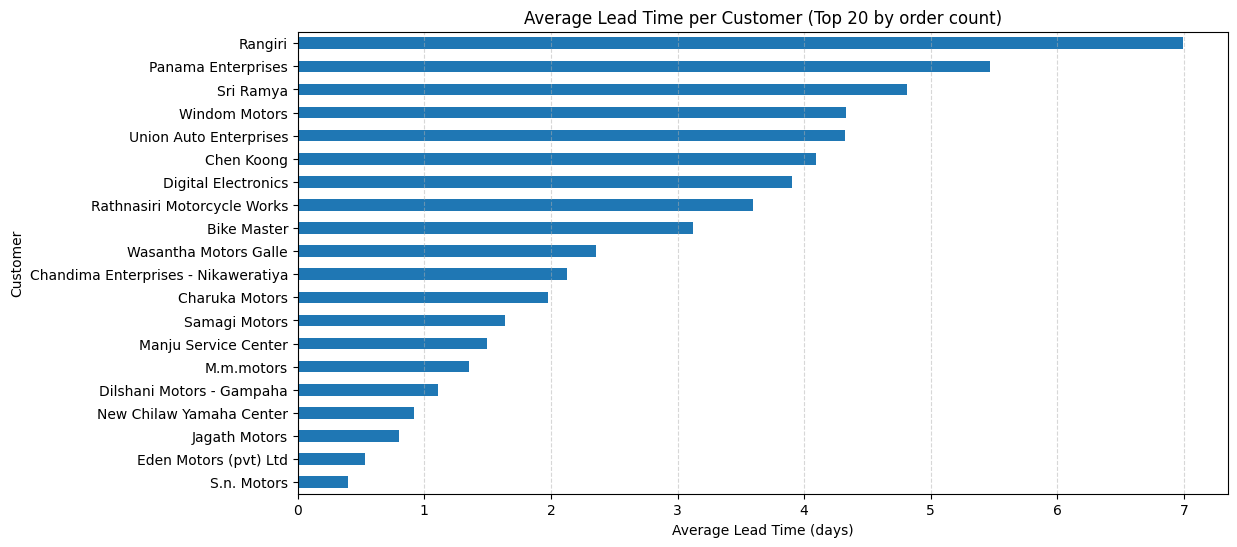

Sold-To Party Name
Union Auto Enterprises                 3059
S.n. Motors                             919
Manju Service Center                    731
Rangiri                                 712
Wasantha Motors Galle                   676
Rathnasiri Motorcycle Works             664
Digital Electronics                     634
Chandima Enterprises - Nikaweratiya     625
Chen Koong                              611
Windom Motors                           605
Dilshani Motors - Gampaha               582
Sri Ramya                               568
Charuka Motors                          566
Panama Enterprises                      562
Samagi Motors                           557
Bike Master                             534
New Chilaw Yamaha Center                524
Eden Motors (pvt) Ltd                   524
M.m.motors                              524
Jagath Motors                           501
Gunawardana Sons                        490
Union Motors                            485
Modern  Motor

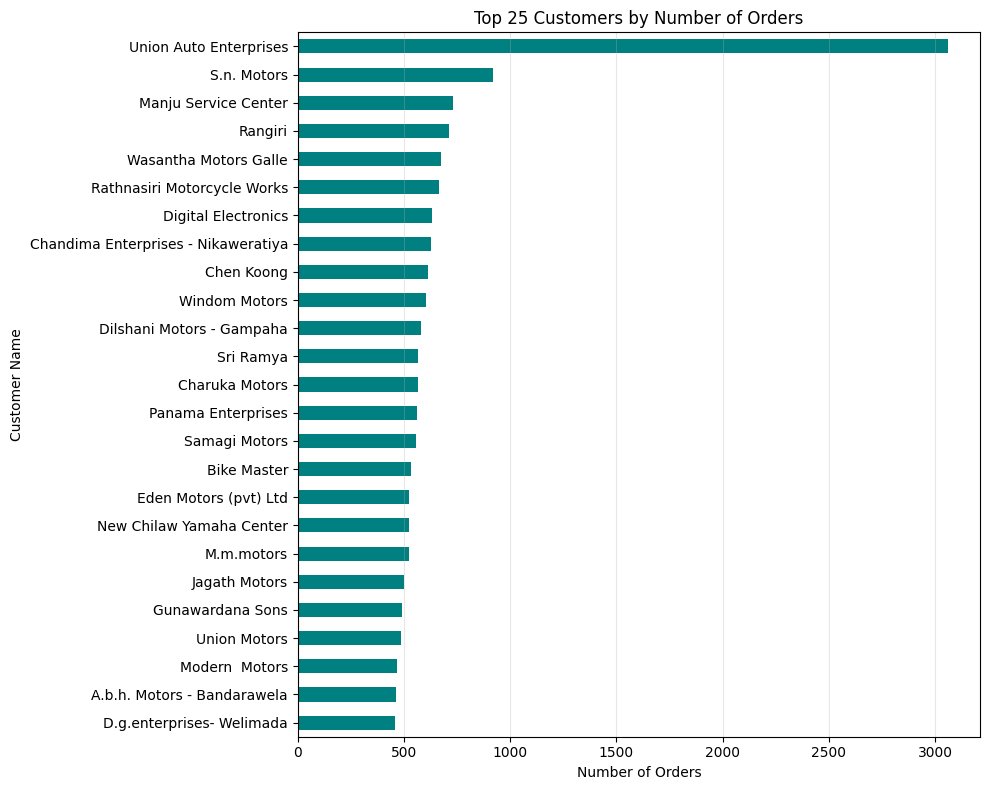


Number of rows with negative Lead Time: 0

Average Lead Time by Sales Document Type
Sales Document Type
ZP1A    4.746613
ZP2A    1.466268
ZRE     0.000000
Name: Lead Time, dtype: float64

Average Lead Time by Sold-To Party Name
Sold-To Party Name
Nalinda Super Motors                 109.091346
Police Transport Division - Parts    102.000000
New Nikko Motors                      50.947581
New Indika Motors                     30.608434
Gasith Rent A Car And cab service     25.974359
Jayani Motors                         20.000000
Anuradha Motors                       20.000000
Rienze Motors                         15.184211
Hemsi Group                           12.943343
Jaya Sri  Motors                      12.666667
Name: Lead Time, dtype: float64

Average Lead Time by Overall Status
Overall Status
B    4.955663
C    2.878160
A    2.621495
Name: Lead Time, dtype: float64

Orders with Lead Time > 30 days: 1160


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove rows where Lead Time is missing (optional but recommended)
clean_orders = orders_df[orders_df['Lead Time'].notna()].copy()

# 1. Basic statistics
print("Lead Time Statistics (days)")
print(clean_orders['Lead Time'].describe())

# 2. Histogram – y‑axis = number of orders
plt.figure(figsize=(10,5))
plt.hist(clean_orders['Lead Time'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Lead Time')
plt.grid(True, linestyle='--', alpha=0.25)
plt.show()

# 3. Boxplot – y‑axis = lead time in days
plt.figure(figsize=(8,5))
sns.boxplot(y=clean_orders['Lead Time'])
plt.ylabel('Lead Time (days)')
plt.title('Boxplot of Lead Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Average lead time by customer (top 20 customers by number of orders)
top_customers = clean_orders['Sold-To Party Name'].value_counts().head(20).index
avg_by_customer = clean_orders[clean_orders['Sold-To Party Name'].isin(top_customers)] \
                  .groupby('Sold-To Party Name')['Lead Time'].mean().sort_values()

# 5. Average Lead Time per Customer (Top 20 by order count)
plt.figure(figsize=(12,6))
avg_by_customer.plot(kind='barh')
plt.xlabel('Average Lead Time (days)')
plt.ylabel('Customer')
plt.title('Average Lead Time per Customer (Top 20 by order count)')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# Count orders per customer
customer_counts = orders_df['Sold-To Party Name'].value_counts().head(25)

# Display the counts
print(customer_counts)

plt.figure(figsize=(10, 8))
customer_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Top 25 Customers by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


# 6. Check for negative lead times (data errors or returns)
neg_lead = orders_df[orders_df['Lead Time'] < 0]
print(f"\nNumber of rows with negative Lead Time: {len(neg_lead)}")


# 7. Average lead time by key categories
#    (choose columns that make sense for your business)
for col in ['Sales Document Type', 'Sold-To Party Name', 'Overall Status']:
    print(f"\nAverage Lead Time by {col}")
    avg = orders_df.groupby(col)['Lead Time'].mean().sort_values(ascending=False).head(10)
    print(avg)

# 5. Optional: flag outliers (e.g., > 30 days)
orders_df['Is Long Lead'] = orders_df['Lead Time'] > 30
long_lead = orders_df[orders_df['Is Long Lead']]
print(f"\nOrders with Lead Time > 30 days: {len(long_lead)}")

In [10]:
# 1. Keep only rows with valid lead times
lead_df = orders_df[['Sold-To Party Name', 'Lead Time']].dropna(subset=['Lead Time'])

# 2. Group by customer and calculate statistics
customer_lead_summary = lead_df.groupby('Sold-To Party Name')['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# 3. Round average for readability
customer_lead_summary['avg_lead_time'] = customer_lead_summary['avg_lead_time'].round(2)

# 4. Optional: add a column for percentage of positive orders
customer_lead_summary['positive_pct'] = (
    customer_lead_summary['positive_orders'] / customer_lead_summary['total_orders'] * 100
).round(1)

# 5. View the result
print(customer_lead_summary.head(10))  # first 10 rows

# 6. Save to CSV for further use
#customer_lead_summary.to_csv('customer_lead_time_analysis.csv', index=False)

                Sold-To Party Name  min_lead_time  max_lead_time  \
0  A M A MOTORS (PRIVATE ) LIMITED            0.0            0.0   
1      A.b.h. Motors - Bandarawela            0.0           40.0   
2                     A.h.s.motors            0.0           24.0   
3                      A.j. Motors            0.0           17.0   
4           A.m.f.motors (pvt) Ltd            0.0           13.0   
5            Agra Auto Enterprises            0.0            0.0   
6  Ajantha Motots & Service Center            0.0           81.0   
7                     Akash Motors            0.0            3.0   
8                     Amaya Motors            0.0            7.0   
9                     Amila Marine            0.0           21.0   

   avg_lead_time  total_orders  positive_orders  positive_pct  
0           0.00             2                0           0.0  
1           0.82           462               73          15.8  
2           2.31            26               11          42

In [11]:
# Ensure you already have orders_df and the 'Lead Time' column
import pandas as pd

# 1. Keep only rows with valid lead times and needed columns
part_df = orders_df[['Material', 'Material Description', 'Lead Time']].dropna(subset=['Lead Time'])

# 2. Group by material (and description) and calculate statistics
part_lead_summary = part_df.groupby(['Material', 'Material Description'])['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# 3. Round average to 2 decimals
part_lead_summary['avg_lead_time'] = part_lead_summary['avg_lead_time'].round(2)

# 4. Optional: percentage of positive orders
part_lead_summary['positive_pct'] = (
    part_lead_summary['positive_orders'] / part_lead_summary['total_orders'] * 100
).round(1)

# 5. View first rows
print(part_lead_summary.head(10))

# 6. Save to CSV for further analysis
#part_lead_summary.to_csv('part_lead_time_analysis.csv', index=False)

      Material           Material Description  min_lead_time  max_lead_time  \
0  01550M0835A  BOLT,INTAKE MANIFOLD M A-STAR            9.0            9.0   
1  09103M10028          BOLT (10X20) M 800 MC            9.0            9.0   
2  09111M08090         BOLT CONT SHAFT M ALTO            9.0            9.0   
3  09117M12006             BOLT CALIPER M 800            9.0            9.0   
4  09140M12040                WHEEL NUT M 410           11.0           37.0   
5  09159M12042                     NUT M ALTO           10.0           10.0   
6  09159M16004   NUT,COUNTERSHAFT M ESTILO MC            9.0            9.0   
7  09168M14012               GASKET OIL DRAIN            0.0            1.0   
8  09247M14027          PLUG OIL DRAIN M ALTO           10.0           10.0   
9  09283M35032            OIL SEAL DIF: M 800            0.0            0.0   

   avg_lead_time  total_orders  positive_orders  positive_pct  
0            9.0             1                1         100.0  
1 

['Requested P/No', 'sss', 'Latest Part No /JAN', 'Special', 'Description', 'Qty', 'EOD ', 'Stock ', 'On orders w.repl ', 'Revised Order Qty ', 'New QTY (If need to change)', 'Forcasted Monthly sales qty - B2B / WS', 'Compatible models']
             Material                   part_description                       models  total_orders  positive_orders  min_lead  max_lead  avg_lead  median_lead  positive_pct
2533        571901NAE                 YAMALUBE 20W40 YAM                      Unknown           856              192       0.0     101.0       2.0          0.0          22.4
2534        571902NAE                 YAMALUBE 10W40 YAM                      Unknown           688              170       0.0     101.0       2.6          0.0          24.7
2532        571837NAE              YAMALUBE MB 10W40 YAM                      Unknown           463              110       0.0     101.0       2.2          0.0          23.8
328      1GC-E7632-01                             WEIGHT  Ray ZR,Ra

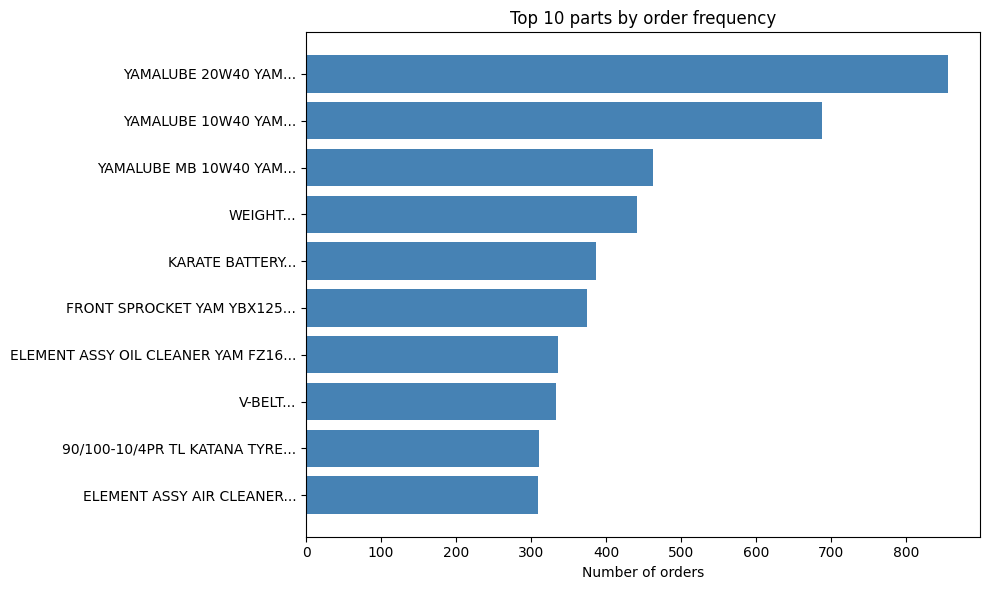

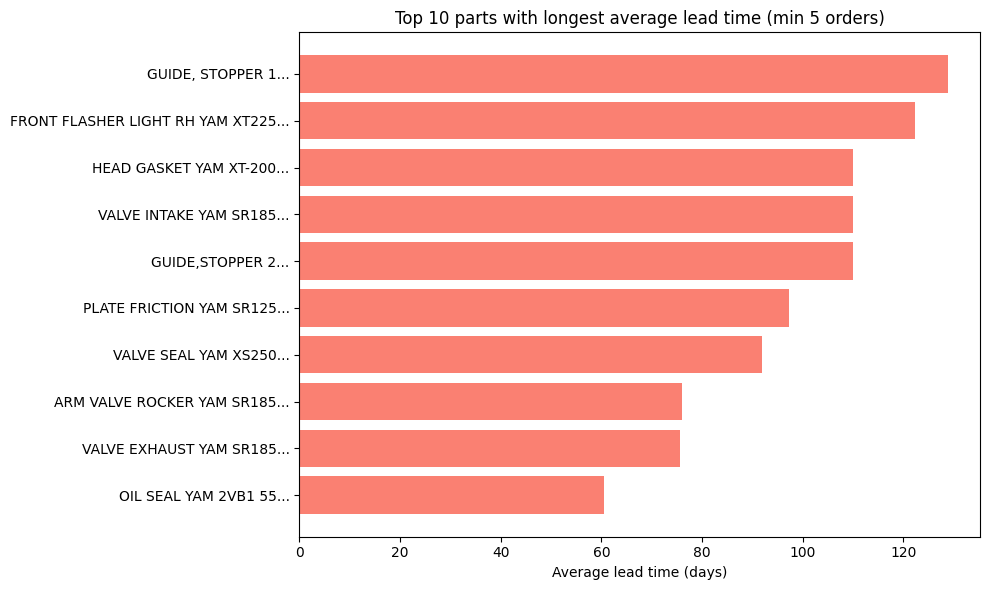

<Figure size 1000x600 with 0 Axes>

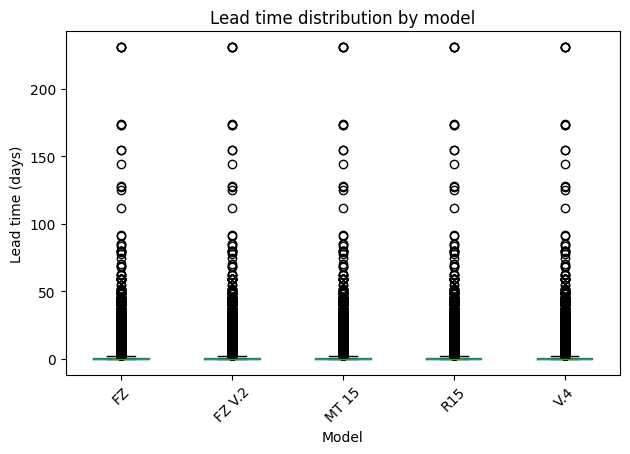

In [14]:
# ----- 1. Load the SSOP file -----
ssop_df = pd.read_excel("SSOP.xlsx")

# Look at its columns
print(ssop_df.columns.tolist())
# We are interested in: 'Requested P/No', 'Description', 'Compatible models'

# ----- 2. Prepare a clean part number column in SSOP -----
# Use 'Requested P/No' as the main identifier; sometimes it may be updated.
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()

# Keep only necessary columns to avoid duplication
ssop_clean = ssop_df[['PartNumber', 'Description', 'Compatible models']].copy()
# Drop duplicates (same part may appear multiple times; take first)
ssop_clean = ssop_clean.drop_duplicates(subset='PartNumber')

# ----- 3. Merge with orders_df -----
# orders_df already contains 'Material' and 'Lead Time'
orders_df['Material'] = orders_df['Material'].astype(str).str.strip()

merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# Now we have a column 'Compatible models' (may contain NaN if no match)

# ----- 4. Part‑wise lead time statistics -----
# Keep only rows with valid lead time
part_stats = merged_df[merged_df['Lead Time'].notna()].copy()

# Group by part number (Material) and include the model info (take first non‑null)
part_summary = part_stats.groupby('Material').agg(
    part_description=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lead Time', 'count'),
    positive_orders=('Lead Time', lambda x: (x > 0).sum()),
    min_lead=('Lead Time', 'min'),
    max_lead=('Lead Time', 'max'),
    avg_lead=('Lead Time', 'mean'),
    median_lead=('Lead Time', 'median')
).reset_index()

# Round averages
part_summary['avg_lead'] = part_summary['avg_lead'].round(1)
part_summary['median_lead'] = part_summary['median_lead'].round(1)

# Add positive percentage
part_summary['positive_pct'] = (part_summary['positive_orders'] / part_summary['total_orders'] * 100).round(1)

# Sort by total orders descending to see most frequent parts
part_summary = part_summary.sort_values('total_orders', ascending=False)

# Display top 20
print(part_summary.head(20).to_string())

# Save to CSV for further use
#part_summary.to_csv('part_lead_time_with_models.csv', index=False)

# Create a copy where we split the 'Compatible models' into a list
model_df = part_stats.copy()
model_df['models_list'] = model_df['Compatible models'].str.split(',')

# Explode so each model gets its own row
model_exploded = model_df.explode('models_list')
# Clean up model names (strip whitespace)
model_exploded['models_list'] = model_exploded['models_list'].str.strip()

# Remove rows where model is empty or NaN
model_exploded = model_exploded[model_exploded['models_list'].notna() & (model_exploded['models_list'] != '')]

# Now we can compute model‑wise statistics
model_stats = model_exploded.groupby('models_list')['Lead Time'].agg(
    total_orders='count',
    avg_lead='mean',
    median_lead='median',
    min_lead='min',
    max_lead='max'
).reset_index().sort_values('total_orders', ascending=False)

model_stats['avg_lead'] = model_stats['avg_lead'].round(1)
model_stats['median_lead'] = model_stats['median_lead'].round(1)

print("\nModel‑wise lead time summary:")
print(model_stats.head(10).to_string())

# Save model summary
#model_stats.to_csv('model_lead_time_summary.csv', index=False)

top_parts = part_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_parts)), top_parts['total_orders'].values, color='steelblue')
plt.yticks(range(len(top_parts)), top_parts['part_description'].str[:40] + '...')
plt.xlabel('Number of orders')
plt.title('Top 10 parts by order frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

freq_parts = part_summary[part_summary['total_orders'] >= 5].copy()
long_lead = freq_parts.nlargest(10, 'avg_lead')

plt.figure(figsize=(10,6))
plt.barh(range(len(long_lead)), long_lead['avg_lead'].values, color='salmon')
plt.yticks(range(len(long_lead)), long_lead['part_description'].str[:40] + '...')
plt.xlabel('Average lead time (days)')
plt.title('Top 10 parts with longest average lead time (min 5 orders)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_models = model_stats.head(5)['models_list'].tolist()
model_subset = model_exploded[model_exploded['models_list'].isin(top_models)]

plt.figure(figsize=(10,6))
model_subset.boxplot(column='Lead Time', by='models_list', grid=False)
plt.title('Lead time distribution by model')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Lead time (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Total lost quantity across all orders: 149,162
Average lost quantity per order: 2.84
Orders with lost quantity (>0): 15708
Orders with over‑delivery (<0): 0

Top 10 parts by total lost quantity:
       Material                          part_desc                      models  total_orders  total_lost  avg_lost  max_lost
   1GC-E7632-01                             WEIGHT Ray ZR,Ray ZR Street Rallay           441      5836.0     13.23     350.0
   21C-E3440-01           ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           198      5288.0     26.71     300.0
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      4978.0     62.22    1000.0
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            48      4958.0    103.29    1000.0
21C-E3440-01-00  ELEMENT ASSY OIL CLEANER YAM FZ16                     Unknown           336      4890.0     14.55     200.0
    94701-00254                PLUG, SPARK (C7HSA)     

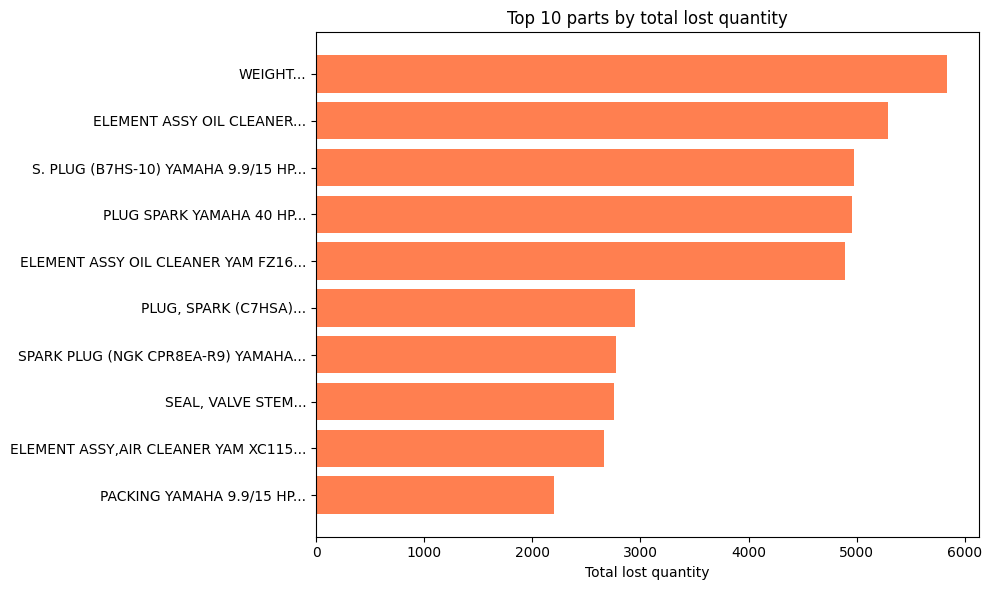


Top 10 customers by total lost quantity:
                 Sold-To Party Name  total_orders  total_lost  avg_lost
             Union Auto Enterprises          3059      8033.0  2.626022
           New Chilaw Yamaha Center           524      5414.0 10.332061
                    Azhakan Traders           339      3906.0 11.522124
                  New Indika Motors           332      2951.0  8.888554
                         Chen Koong           611      2913.0  4.767594
              Wasantha Motors Galle           676      2871.0  4.247041
Chandima Enterprises - Nikaweratiya           625      2676.0  4.281600
                        S.n. Motors           919      2601.0  2.830250
                        Hemsi Group           353      2577.0  7.300283
               Manju Service Center           731      2570.0  3.515732


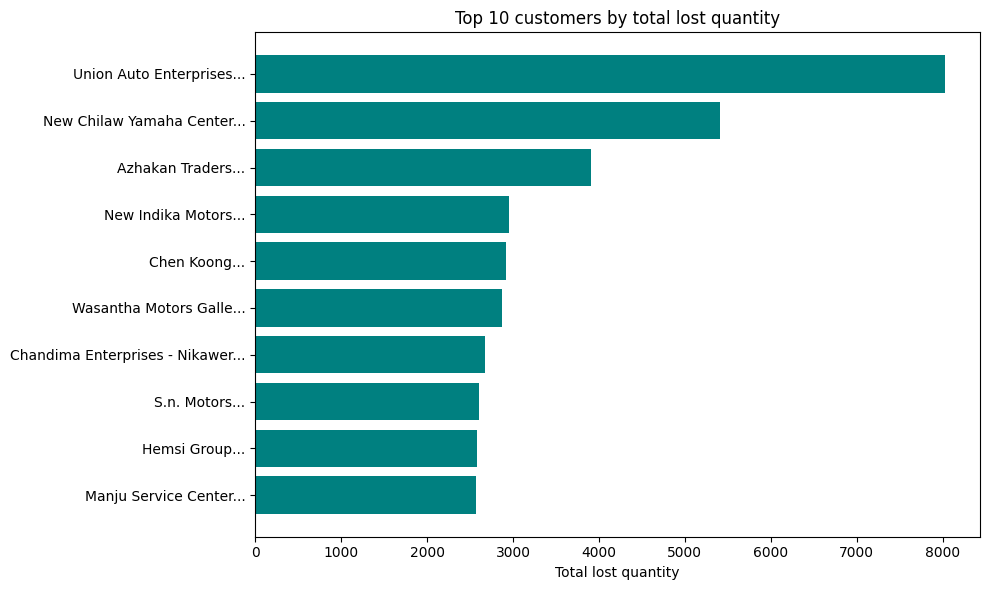


Top 10 models by total lost quantity:
              models  total_orders  total_lost  avg_lost
                  FZ         10370     32390.4  3.123472
              FZ V.2         10370     32390.4  3.123472
               MT 15         10370     32390.4  3.123472
                 R15         10370     32390.4  3.123472
                 V.4         10370     32390.4  3.123472
              Ray ZR          7071     27303.0  3.861264
Ray ZR Street Rallay          7071     27303.0  3.861264
              COMMON           856      7078.0  8.268692


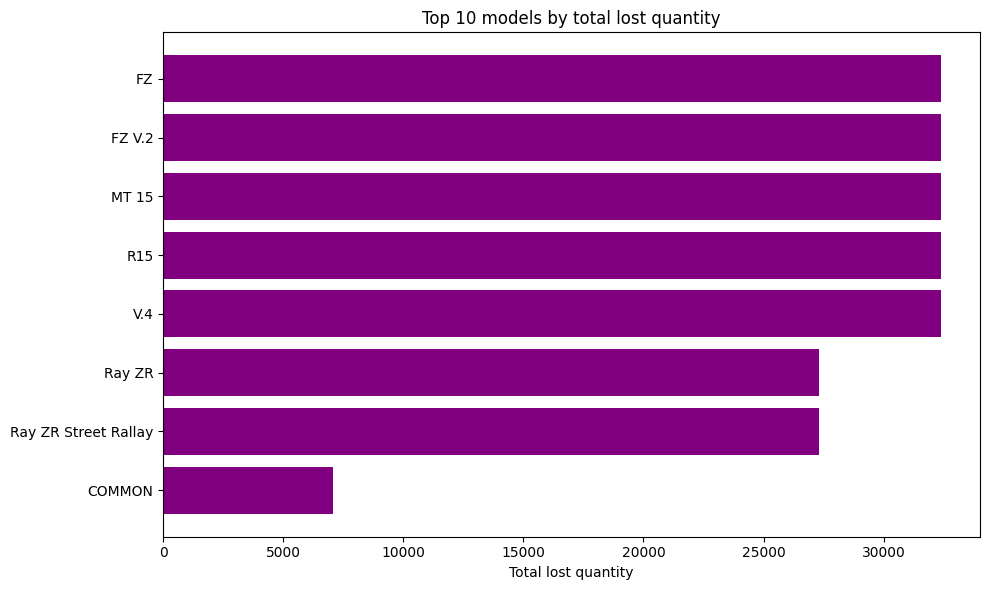

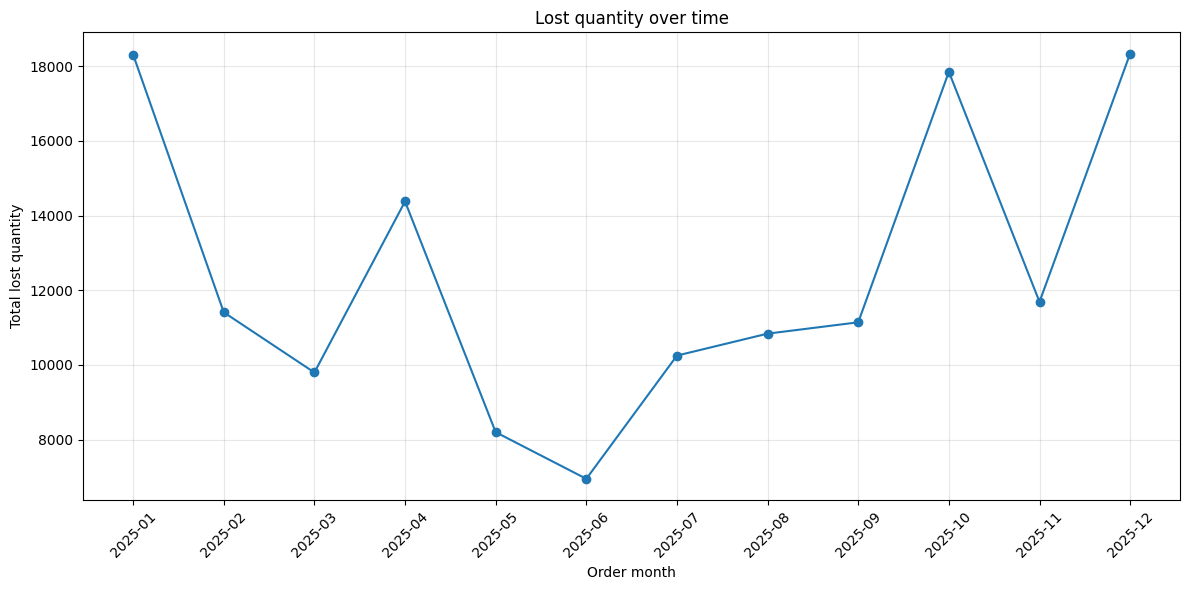

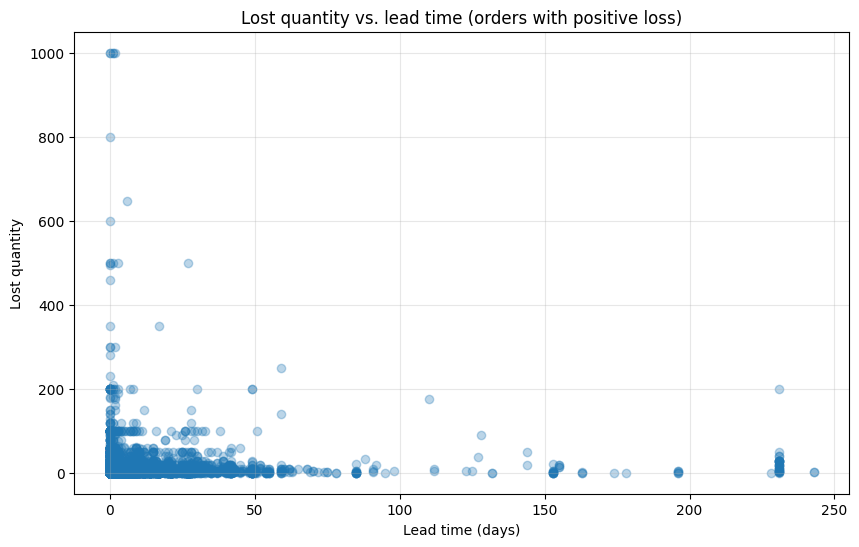

In [17]:
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Compatible models']].drop_duplicates(subset='PartNumber')

# Merge
orders_df['Material'] = orders_df['Material'].astype(str).str.strip()
merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# Basic stats
total_lost = merged_df['Lost Qty'].sum()
avg_lost_per_order = merged_df['Lost Qty'].mean()
orders_with_loss = (merged_df['Lost Qty'] > 0).sum()
orders_with_overdelivery = (merged_df['Lost Qty'] < 0).sum()

print(f"Total lost quantity across all orders: {total_lost:,.0f}")
print(f"Average lost quantity per order: {avg_lost_per_order:.2f}")
print(f"Orders with lost quantity (>0): {orders_with_loss}")
print(f"Orders with over‑delivery (<0): {orders_with_overdelivery}")

# Group by part number
part_lost = merged_df.groupby('Material').agg(
    part_desc=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean'),
    max_lost=('Lost Qty', 'max')
).reset_index()

part_lost = part_lost.sort_values('total_lost', ascending=False)
part_lost['avg_lost'] = part_lost['avg_lost'].round(2)

print("\nTop 10 parts by total lost quantity:")
print(part_lost.head(10).to_string(index=False))

# Visualize
top10_parts = part_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_parts)), top10_parts['total_lost'].values, color='coral')
plt.yticks(range(len(top10_parts)), top10_parts['part_desc'].str[:40] + '...')
plt.xlabel('Total lost quantity')
plt.title('Top 10 parts by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

cust_lost = merged_df.groupby('Sold-To Party Name').agg(
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean')
).reset_index().sort_values('total_lost', ascending=False)

print("\nTop 10 customers by total lost quantity:")
print(cust_lost.head(10).to_string(index=False))

# Bar chart
top10_cust = cust_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_cust)), top10_cust['total_lost'].values, color='teal')
plt.yticks(range(len(top10_cust)), top10_cust['Sold-To Party Name'].str[:30] + '...')
plt.xlabel('Total lost quantity')
plt.title('Top 10 customers by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create exploded model column
model_df = merged_df.copy()
model_df['models'] = model_df['Compatible models'].str.split(',')

# Explode so each model gets its own row
model_exploded = model_df.explode('models')
model_exploded['models'] = model_exploded['models'].str.strip()
model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

# Aggregate by model
model_lost = model_exploded.groupby('models').agg(
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean')
).reset_index().sort_values('total_lost', ascending=False)

print("\nTop 10 models by total lost quantity:")
print(model_lost.head(10).to_string(index=False))

# Bar chart
top10_models = model_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_models)), top10_models['total_lost'].values, color='purple')
plt.yticks(range(len(top10_models)), top10_models['models'])
plt.xlabel('Total lost quantity')
plt.title('Top 10 models by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create a monthly period (or daily) to see trend
merged_df['Order Month'] = merged_df['Created On'].dt.to_period('M')
monthly_lost = merged_df.groupby('Order Month')['Lost Qty'].sum().reset_index()
monthly_lost['Order Month'] = monthly_lost['Order Month'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_lost['Order Month'], monthly_lost['Lost Qty'], marker='o')
plt.xlabel('Order month')
plt.ylabel('Total lost quantity')
plt.title('Lost quantity over time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot: lost qty vs lead time for orders with positive lost
pos_lost = merged_df[merged_df['Lost Qty'] > 0].copy()
plt.figure(figsize=(10,6))
plt.scatter(pos_lost['Lead Time'], pos_lost['Lost Qty'], alpha=0.3)
plt.xlabel('Lead time (days)')
plt.ylabel('Lost quantity')
plt.title('Lost quantity vs. lead time (orders with positive loss)')
plt.grid(True, alpha=0.3)
plt.show()

Total lost sales value: 151,998,872.67 LKR
Average lost sales per order: 2,897.81 LKR
Orders with positive lost sales: 15660
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                          part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
1GC-WE661-10-00                CYLINDER PISTON KIT                     Unknown            77      2.634203e+06        34210.42
   2RB-14940-00                     DIAPHRAGM ASSY Ray ZR,Ray ZR Street Rallay           201      2.453050e+06        12204.23
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      2.374506e+06        29681.32
      571902NAE                 YAMALUBE 10W40 YAM                     Unknown           688      2.252989e+06         3274.69
   4EB-23145-01                  OIL SEAL YAM FZ16   FZ V.2,MT 15,FZ,V.4, R15,           165      2.226525e+06        13494.09
1GC-E4450-00-00 ELEMENT ASS

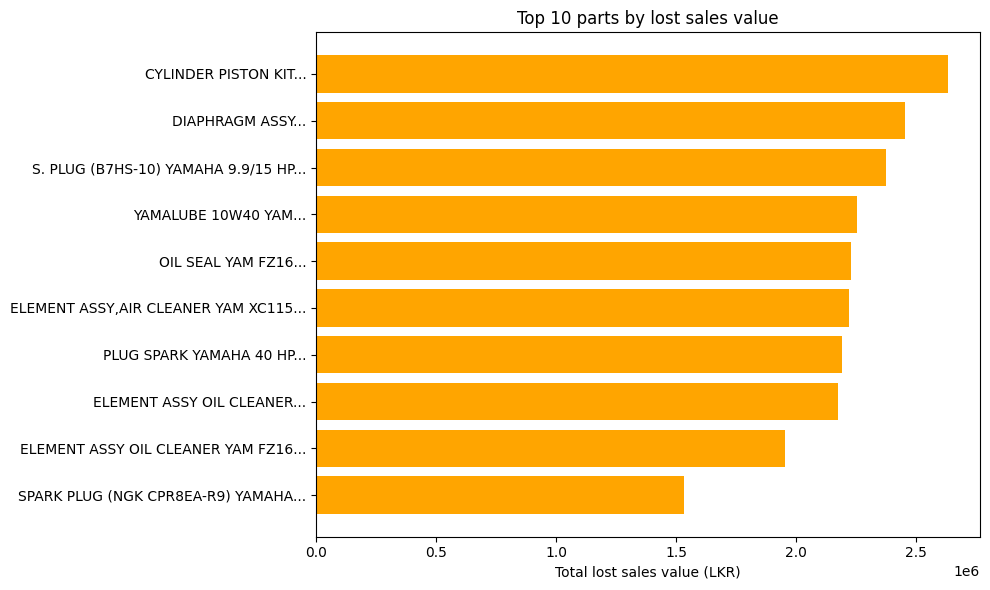


Top 10 customers by total lost sales value:
                   Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
               Union Auto Enterprises          3059      8.419668e+06     2752.425045
Fernando Auto House (private) Limited            35      5.554906e+06   158711.610371
                      Azhakan Traders           339      3.784184e+06    11162.785939
                    Wijesinghe Motors           432      3.638983e+06     8423.572885
             New Chilaw Yamaha Center           524      3.619324e+06     6907.106471
                    New Indika Motors           332      3.261839e+06     9824.815384
                Wasantha Motors Galle           676      3.244583e+06     4799.678411
                           Chen Koong           611      2.773076e+06     4538.586412
  Chandima Enterprises - Nikaweratiya           625      2.722570e+06     4356.111532
                        Windom Motors           605      2.570576e+06     4248.885271


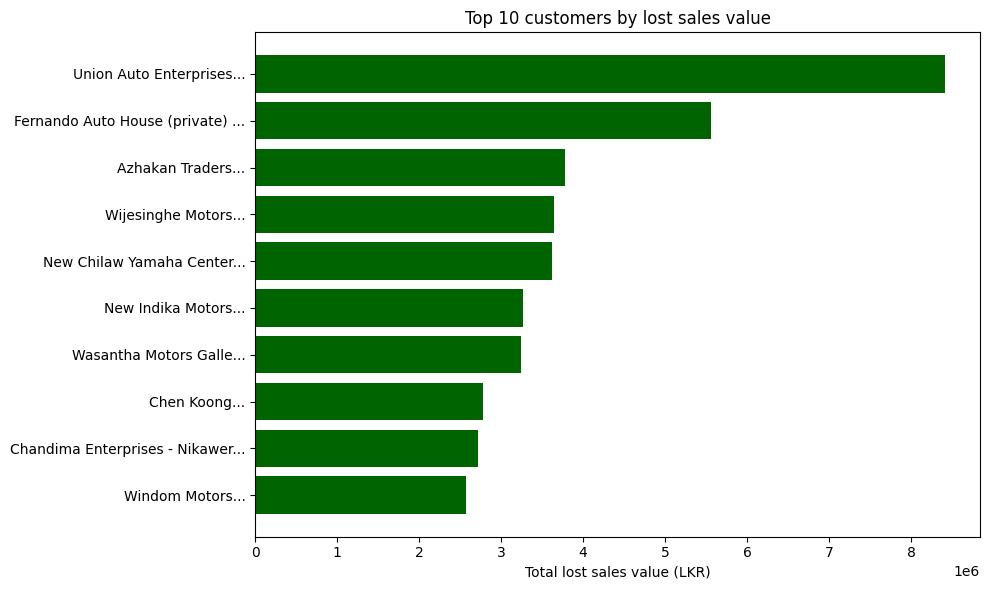


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ         10370      2.835518e+07     2734.347024
              FZ V.2         10370      2.835518e+07     2734.347024
               MT 15         10370      2.835518e+07     2734.347024
                 R15         10370      2.835518e+07     2734.347024
                 V.4         10370      2.835518e+07     2734.347024
              Ray ZR          7071      1.813051e+07     2564.066025
Ray ZR Street Rallay          7071      1.813051e+07     2564.066025
              COMMON           856      3.502136e+06     4091.280081


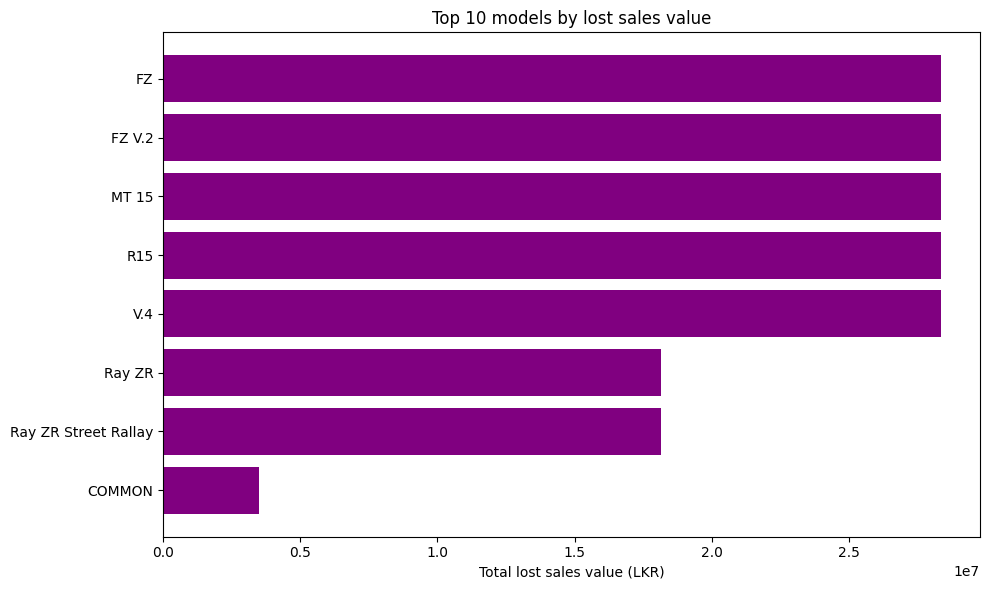

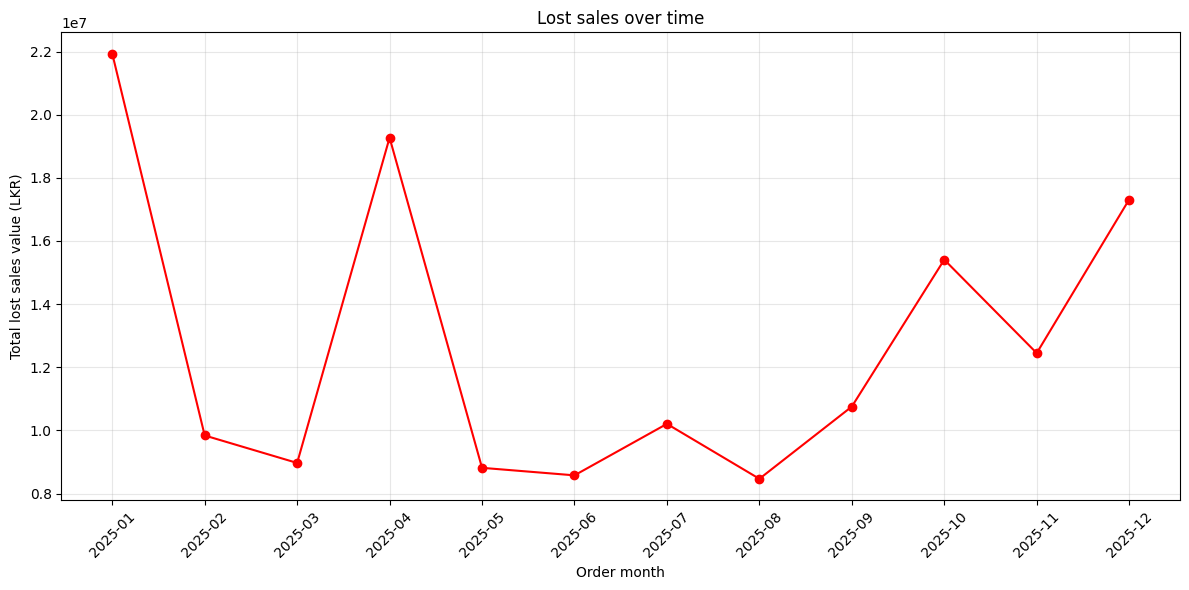

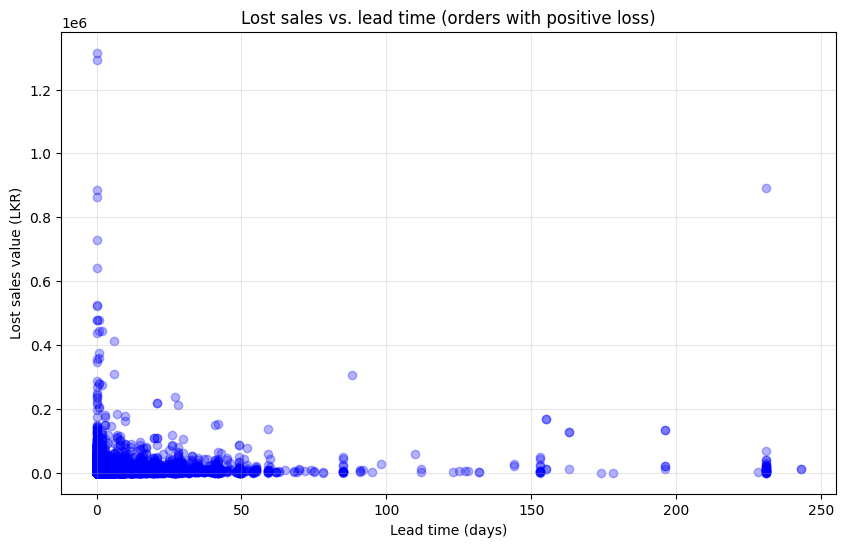

In [18]:
# Avoid division by zero
merged_df['Unit Price'] = merged_df.apply(
    lambda row: row['Net Value (Item)'] / row['Order Quantity (Item)']
    if pd.notna(row['Net Value (Item)']) and pd.notna(row['Order Quantity (Item)']) and row['Order Quantity (Item)'] > 0
    else 0,
    axis=1
)

merged_df['Lost Sales Value'] = merged_df['Lost Qty'] * merged_df['Unit Price']

total_lost_sales = merged_df['Lost Sales Value'].sum()
avg_lost_sales_per_order = merged_df['Lost Sales Value'].mean()
orders_with_lost_sales = (merged_df['Lost Sales Value'] > 0).sum()
orders_with_negative_lost = (merged_df['Lost Sales Value'] < 0).sum()   # over‑delivery

print(f"Total lost sales value: {total_lost_sales:,.2f} LKR")
print(f"Average lost sales per order: {avg_lost_sales_per_order:,.2f} LKR")
print(f"Orders with positive lost sales: {orders_with_lost_sales}")
print(f"Orders with over‑delivery (negative lost): {orders_with_negative_lost}")

part_lost_sales = merged_df.groupby('Material').agg(
    part_desc=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lost Sales Value', 'count'),
    total_lost_sales=('Lost Sales Value', 'sum'),
    avg_lost_sales=('Lost Sales Value', 'mean')
).reset_index().sort_values('total_lost_sales', ascending=False)

part_lost_sales['avg_lost_sales'] = part_lost_sales['avg_lost_sales'].round(2)

print("\nTop 10 parts by total lost sales value:")
print(part_lost_sales.head(10).to_string(index=False))

# Visualize
top10_parts = part_lost_sales.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_parts)), top10_parts['total_lost_sales'].values, color='orange')
plt.yticks(range(len(top10_parts)), top10_parts['part_desc'].str[:40] + '...')
plt.xlabel('Total lost sales value (LKR)')
plt.title('Top 10 parts by lost sales value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

cust_lost_sales = merged_df.groupby('Sold-To Party Name').agg(
    total_orders=('Lost Sales Value', 'count'),
    total_lost_sales=('Lost Sales Value', 'sum'),
    avg_lost_sales=('Lost Sales Value', 'mean')
).reset_index().sort_values('total_lost_sales', ascending=False)

print("\nTop 10 customers by total lost sales value:")
print(cust_lost_sales.head(10).to_string(index=False))

top10_cust = cust_lost_sales.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_cust)), top10_cust['total_lost_sales'].values, color='darkgreen')
plt.yticks(range(len(top10_cust)), top10_cust['Sold-To Party Name'].str[:30] + '...')
plt.xlabel('Total lost sales value (LKR)')
plt.title('Top 10 customers by lost sales value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

model_df = merged_df.copy()
model_df['models'] = model_df['Compatible models'].str.split(',')

model_exploded = model_df.explode('models')
model_exploded['models'] = model_exploded['models'].str.strip()
model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

model_lost_sales = model_exploded.groupby('models').agg(
    total_orders=('Lost Sales Value', 'count'),
    total_lost_sales=('Lost Sales Value', 'sum'),
    avg_lost_sales=('Lost Sales Value', 'mean')
).reset_index().sort_values('total_lost_sales', ascending=False)

print("\nTop 10 models by total lost sales value:")
print(model_lost_sales.head(10).to_string(index=False))

top10_models = model_lost_sales.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_models)), top10_models['total_lost_sales'].values, color='purple')
plt.yticks(range(len(top10_models)), top10_models['models'])
plt.xlabel('Total lost sales value (LKR)')
plt.title('Top 10 models by lost sales value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

merged_df['Order Month'] = merged_df['Created On'].dt.to_period('M')
monthly_lost_sales = merged_df.groupby('Order Month')['Lost Sales Value'].sum().reset_index()
monthly_lost_sales['Order Month'] = monthly_lost_sales['Order Month'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_lost_sales['Order Month'], monthly_lost_sales['Lost Sales Value'], marker='o', color='red')
plt.xlabel('Order month')
plt.ylabel('Total lost sales value (LKR)')
plt.title('Lost sales over time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pos_lost_sales = merged_df[merged_df['Lost Sales Value'] > 0].copy()
plt.figure(figsize=(10,6))
plt.scatter(pos_lost_sales['Lead Time'], pos_lost_sales['Lost Sales Value'], alpha=0.3, color='blue')
plt.xlabel('Lead time (days)')
plt.ylabel('Lost sales value (LKR)')
plt.title('Lost sales vs. lead time (orders with positive loss)')
plt.grid(True, alpha=0.3)
plt.show()



In [19]:
# Create a boolean column indicating cancellation
orders_df['Is Cancelled'] = orders_df['Rejection Reason Description'].notna() & (orders_df['Rejection Reason Description'] != '')

# Basic statistics
total_orders = len(orders_df)
cancelled_orders = orders_df['Is Cancelled'].sum()
cancelled_percentage = (cancelled_orders / total_orders) * 100

print(f"Total orders: {total_orders}")
print(f"Cancelled orders: {cancelled_orders}")
print(f"Cancellation rate: {cancelled_percentage:.2f}%")

# Show a few cancelled orders as example
print("\nSample of cancelled orders:")
cancelled_sample = orders_df[orders_df['Is Cancelled']][['Sales Document', 'Rejection Reason Description']].head(10)
print(cancelled_sample.to_string(index=False))

Total orders: 52453
Cancelled orders: 15517
Cancellation rate: 29.58%

Sample of cancelled orders:
 Sales Document Rejection Reason Description
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order
       60011551              Duplicate Order


=== Cancellation Overview ===
Total orders: 52453
Cancelled orders: 15517 (29.6%)
Active orders: 36936 (70.4%)

=== Cancellation Reasons ===
Rejection Reason Description
Order cancelled by customer                 15282
Duplicate Order                               155
NOT  AVAILABLE                                 16
Wrong Order Type by SE                         16
Order Cancelled by Supplier                    12
Out of Stock at Location                       10
PA-No stock (first time Pick)                  10
System Error                                    9
NOT DONE                                        2
No Mould Available                              1
Sidewall Damage Severe                          1
Pending Settlement  - Over 60 days debts        1
Ply Separation                                  1
Damage Goods                                    1


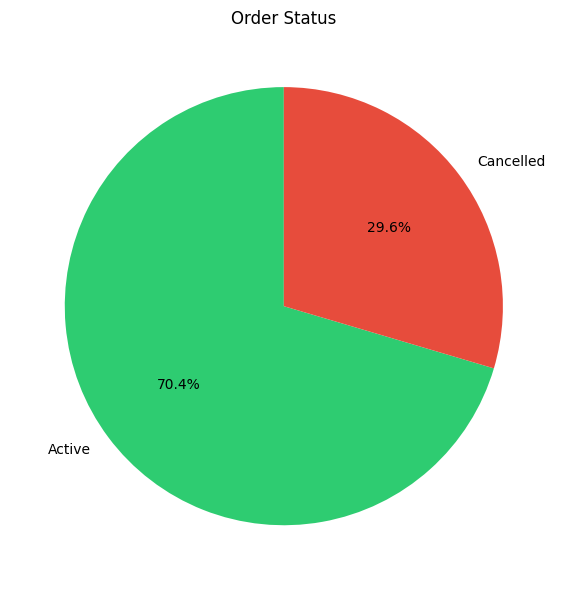


=== Top 5 customers with most cancellations ===
Sold-To Party Name
Union Auto Enterprises    2046
S.n. Motors                530
Rangiri                    367
Digital Electronics        310
Chen Koong                 287

=== Cancellations by Sales Document Type ===
Sales Document Type
ZP1A    12659
ZP2A     2792
ZRE        66


In [20]:
# 1. Overall cancellation summary
total = len(orders_df)
cancelled = orders_df['Is Cancelled'].sum()
active = total - cancelled

print("=== Cancellation Overview ===")
print(f"Total orders: {total}")
print(f"Cancelled orders: {cancelled} ({cancelled/total*100:.1f}%)")
print(f"Active orders: {active} ({active/total*100:.1f}%)")

# 2. Breakdown by rejection reason (only for cancelled orders)
reason_counts = orders_df.loc[orders_df['Is Cancelled'], 'Rejection Reason Description'].value_counts()
print("\n=== Cancellation Reasons ===")
print(reason_counts.to_string())

# 3. Simple pie chart of cancelled vs active
plt.figure(figsize=(6,6))
plt.pie([active, cancelled], labels=['Active', 'Cancelled'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Order Status')
plt.tight_layout()
plt.show()

# 4. Optional: cancelled orders by customer (top 5)
cust_cancel = orders_df[orders_df['Is Cancelled']]['Sold-To Party Name'].value_counts().head(5)
print("\n=== Top 5 customers with most cancellations ===")
print(cust_cancel.to_string())

# 5. Optional: cancelled orders by sales document type
type_cancel = orders_df[orders_df['Is Cancelled']]['Sales Document Type'].value_counts()
print("\n=== Cancellations by Sales Document Type ===")
print(type_cancel.to_string())

Lead Time Statistics for Non‑Cancelled Orders (days)
count    36935.000000
mean         2.356681
std         13.308439
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        348.000000
Name: Lead Time, dtype: float64


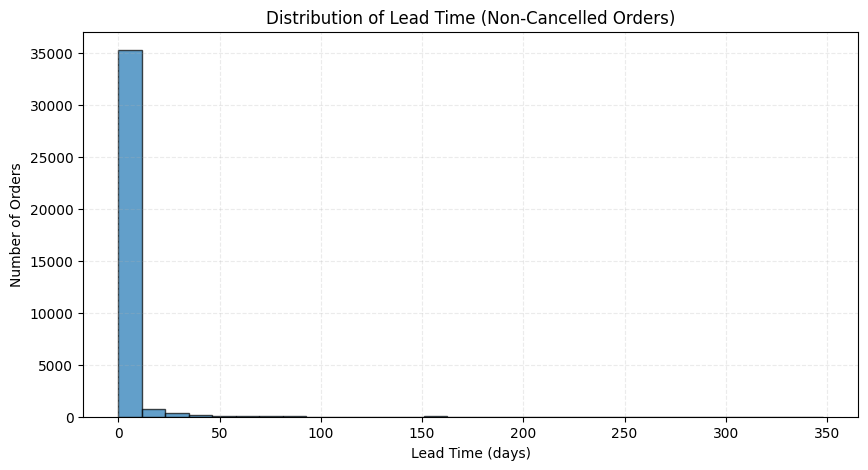

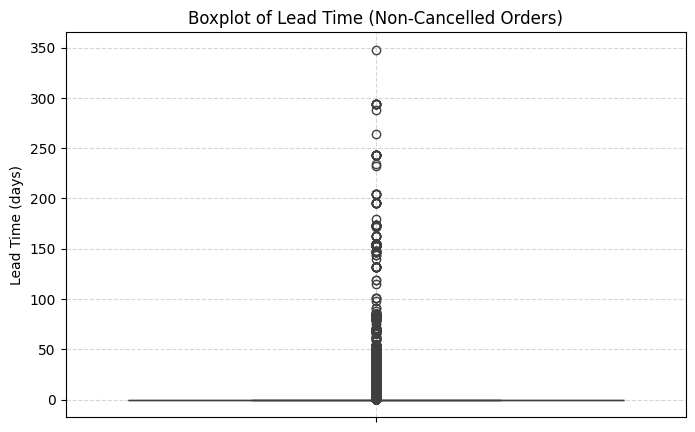

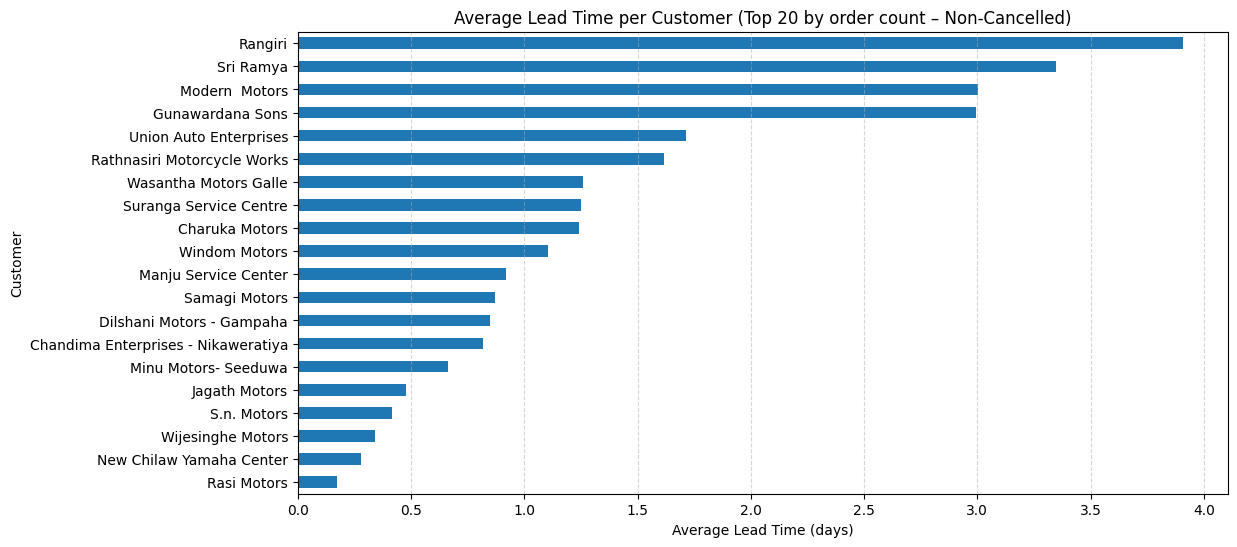

Top 25 Customers by Number of Orders (Non‑Cancelled)
Sold-To Party Name
Union Auto Enterprises                 1013
Wasantha Motors Galle                   521
Manju Service Center                    514
Jagath Motors                           490
Samagi Motors                           462
Modern  Motors                          451
Chandima Enterprises - Nikaweratiya     427
Rasi Motors                             422
Sri Ramya                               415
Dilshani Motors - Gampaha               414
Rathnasiri Motorcycle Works             396
Charuka Motors                          395
Gunawardana Sons                        393
S.n. Motors                             389
New Chilaw Yamaha Center                370
Minu Motors- Seeduwa                    349
Rangiri                                 345
Windom Motors                           342
Wijesinghe Motors                       337
Suranga Service Centre                  336
Digital Electronics                     324
Chen

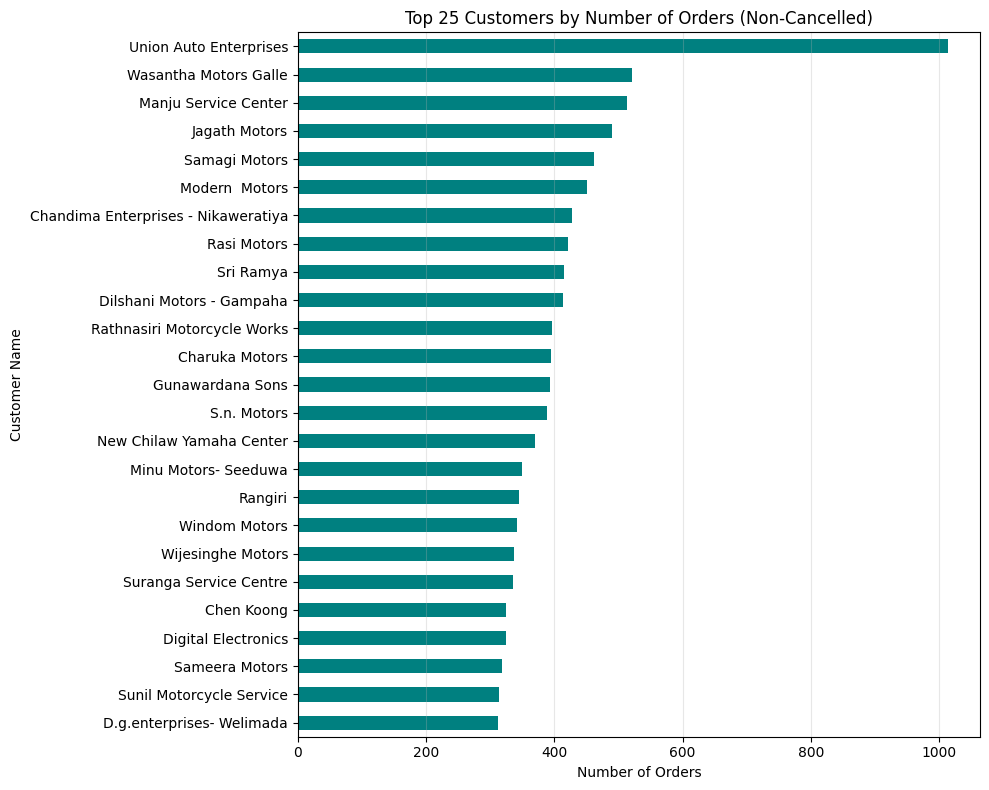


Number of rows with negative Lead Time (Non‑Cancelled): 0

Average Lead Time by Sales Document Type (Non‑Cancelled)
Sales Document Type
ZP1A    3.524137
ZP2A    1.290595
ZRE     0.000000
Name: Lead Time, dtype: float64

Average Lead Time by Sold-To Party Name (Non‑Cancelled)
Sold-To Party Name
Police Transport Division - Parts      203.000000
Nalinda Super Motors                   110.150485
New Nikko Motors                        55.372807
Gasith Rent A Car And cab service       26.770270
Jaya Sri  Motors                        18.760000
New Jayasekara Auto Motors (pvt) lt     12.090909
Rienze Motors                           10.804878
Halford Care                             9.500000
Thilanka Motors                          8.777778
Neranjan Marine Centre                   8.615385
Name: Lead Time, dtype: float64

Average Lead Time by Overall Status (Non‑Cancelled)
Overall Status
B    4.860203
A    2.621495
C    1.208416
Name: Lead Time, dtype: float64

Orders with Lead Time > 30 da

In [21]:
# ----- 1. Filter out cancelled orders -----
# Use the 'Is Cancelled' column created earlier (True if Rejection Reason is not empty)
non_cancelled = orders_df[orders_df['Is Cancelled'] == False].copy()

# Remove rows with missing Lead Time (optional but recommended)
clean_orders = non_cancelled[non_cancelled['Lead Time'].notna()].copy()

# ----- 2. Basic statistics -----
print("Lead Time Statistics for Non‑Cancelled Orders (days)")
print(clean_orders['Lead Time'].describe())

# ----- 3. Histogram – y‑axis = number of orders -----
plt.figure(figsize=(10,5))
plt.hist(clean_orders['Lead Time'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Lead Time (Non‑Cancelled Orders)')
plt.grid(True, linestyle='--', alpha=0.25)
plt.show()

# ----- 4. Boxplot – y‑axis = lead time in days -----
plt.figure(figsize=(8,5))
sns.boxplot(y=clean_orders['Lead Time'])
plt.ylabel('Lead Time (days)')
plt.title('Boxplot of Lead Time (Non‑Cancelled Orders)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ----- 5. Average lead time by customer (top 20 customers by number of orders) -----
top_customers = clean_orders['Sold-To Party Name'].value_counts().head(20).index
avg_by_customer = clean_orders[clean_orders['Sold-To Party Name'].isin(top_customers)] \
                  .groupby('Sold-To Party Name')['Lead Time'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_by_customer.plot(kind='barh')
plt.xlabel('Average Lead Time (days)')
plt.ylabel('Customer')
plt.title('Average Lead Time per Customer (Top 20 by order count – Non‑Cancelled)')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# ----- 6. Top 25 customers by number of orders (non‑cancelled) -----
customer_counts = clean_orders['Sold-To Party Name'].value_counts().head(25)
print("Top 25 Customers by Number of Orders (Non‑Cancelled)")
print(customer_counts)

plt.figure(figsize=(10, 8))
customer_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Top 25 Customers by Number of Orders (Non‑Cancelled)')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

# ----- 7. Check for negative lead times (data errors or returns) -----
neg_lead = clean_orders[clean_orders['Lead Time'] < 0]
print(f"\nNumber of rows with negative Lead Time (Non‑Cancelled): {len(neg_lead)}")

# ----- 8. Average lead time by key categories (non‑cancelled) -----
for col in ['Sales Document Type', 'Sold-To Party Name', 'Overall Status']:
    print(f"\nAverage Lead Time by {col} (Non‑Cancelled)")
    avg = clean_orders.groupby(col)['Lead Time'].mean().sort_values(ascending=False).head(10)
    print(avg)

# ----- 9. Flag outliers (e.g., > 30 days) -----
clean_orders['Is Long Lead'] = clean_orders['Lead Time'] > 30
long_lead = clean_orders[clean_orders['Is Long Lead']]
print(f"\nOrders with Lead Time > 30 days (Non‑Cancelled): {len(long_lead)}")

In [22]:
# ----- 0. Ensure 'Is Cancelled' column exists -----
# (If not already done, run this line)
orders_df['Is Cancelled'] = orders_df['Rejection Reason Description'].notna() & (orders_df['Rejection Reason Description'] != '')

# ----- 1. Filter to non‑cancelled orders only -----
non_cancelled = orders_df[orders_df['Is Cancelled'] == False].copy()

# ----- 2. Keep only rows with valid lead times -----
lead_df = non_cancelled[['Sold-To Party Name', 'Lead Time']].dropna(subset=['Lead Time'])

# ----- 3. Group by customer and calculate statistics -----
customer_lead_summary = lead_df.groupby('Sold-To Party Name')['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# ----- 4. Round average for readability -----
customer_lead_summary['avg_lead_time'] = customer_lead_summary['avg_lead_time'].round(2)

# ----- 5. Add percentage of positive orders -----
customer_lead_summary['positive_pct'] = (
    customer_lead_summary['positive_orders'] / customer_lead_summary['total_orders'] * 100
).round(1)

# ----- 6. View the result (first 10 rows) -----
print("Customer lead time summary (non‑cancelled orders only):")
print(customer_lead_summary.head(10))

# ----- 7. Save to CSV -----
customer_lead_summary.to_csv('customer_lead_time_analysis_non_cancelled.csv', index=False)

Customer lead time summary (non‑cancelled orders only):
                Sold-To Party Name  min_lead_time  max_lead_time  \
0  A M A MOTORS (PRIVATE ) LIMITED            0.0            0.0   
1      A.b.h. Motors - Bandarawela            0.0           38.0   
2                     A.h.s.motors            0.0            8.0   
3                      A.j. Motors            0.0            1.0   
4           A.m.f.motors (pvt) Ltd            0.0           13.0   
5            Agra Auto Enterprises            0.0            0.0   
6  Ajantha Motots & Service Center            0.0           20.0   
7                     Akash Motors            0.0            3.0   
8                     Amaya Motors            0.0            7.0   
9                     Amila Marine            0.0           21.0   

   avg_lead_time  total_orders  positive_orders  positive_pct  
0           0.00             2                0           0.0  
1           0.46           211                7           3.3  
2  

In [23]:
# ----- 0. Ensure 'Is Cancelled' column exists -----
orders_df['Is Cancelled'] = orders_df['Rejection Reason Description'].notna() & (orders_df['Rejection Reason Description'] != '')

# ----- 1. Filter to non‑cancelled orders only -----
non_cancelled = orders_df[orders_df['Is Cancelled'] == False].copy()

# ----- 2. Keep only rows with valid lead times and needed columns -----
part_df = non_cancelled[['Material', 'Material Description', 'Lead Time']].dropna(subset=['Lead Time'])

# ----- 3. Group by material (and description) and calculate statistics -----
part_lead_summary = part_df.groupby(['Material', 'Material Description'])['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# ----- 4. Round average to 2 decimals -----
part_lead_summary['avg_lead_time'] = part_lead_summary['avg_lead_time'].round(2)

# ----- 5. Optional: percentage of positive orders -----
part_lead_summary['positive_pct'] = (
    part_lead_summary['positive_orders'] / part_lead_summary['total_orders'] * 100
).round(1)

# ----- 6. View first rows -----
print("Part lead time summary (non‑cancelled orders only):")
print(part_lead_summary.head(10))

# ----- 7. Save to CSV for further analysis -----
part_lead_summary.to_csv('part_lead_time_analysis_non_cancelled.csv', index=False)

Part lead time summary (non‑cancelled orders only):
      Material                      Material Description  min_lead_time  \
0  01550M0835A             BOLT,INTAKE MANIFOLD M A-STAR            9.0   
1  09103M10028                     BOLT (10X20) M 800 MC            9.0   
2  09111M08090                    BOLT CONT SHAFT M ALTO            9.0   
3  09117M12006                        BOLT CALIPER M 800            9.0   
4  09140M12040                           WHEEL NUT M 410           11.0   
5  09159M16004              NUT,COUNTERSHAFT M ESTILO MC            9.0   
6  09168M14012                          GASKET OIL DRAIN            0.0   
7  09283M35032                       OIL SEAL DIF: M 800            0.0   
8  09283M35047                           OIL SEAL M ALTO            2.0   
9  09482-00619  SPARK PLUG (ILMAR7A8 NGK) HYBRID WAGON-R            0.0   

   max_lead_time  avg_lead_time  total_orders  positive_orders  positive_pct  
0            9.0           9.00            

['Requested P/No', 'sss', 'Latest Part No /JAN', 'Special', 'Description', 'Qty', 'EOD ', 'Stock ', 'On orders w.repl ', 'Revised Order Qty ', 'New QTY (If need to change)', 'Forcasted Monthly sales qty - B2B / WS', 'Compatible models']

Part lead time summary (non‑cancelled orders):
             Material                   part_description                       models  total_orders  positive_orders  min_lead  max_lead  avg_lead  median_lead  positive_pct
2016        571901NAE                 YAMALUBE 20W40 YAM                      Unknown           749              158       0.0     101.0       1.6          0.0          21.1
2017        571902NAE                 YAMALUBE 10W40 YAM                      Unknown           583              122       0.0     101.0       1.9          0.0          20.9
2015        571837NAE              YAMALUBE MB 10W40 YAM                      Unknown           405               86       0.0     101.0       1.9          0.0          21.2
3219      93822-148

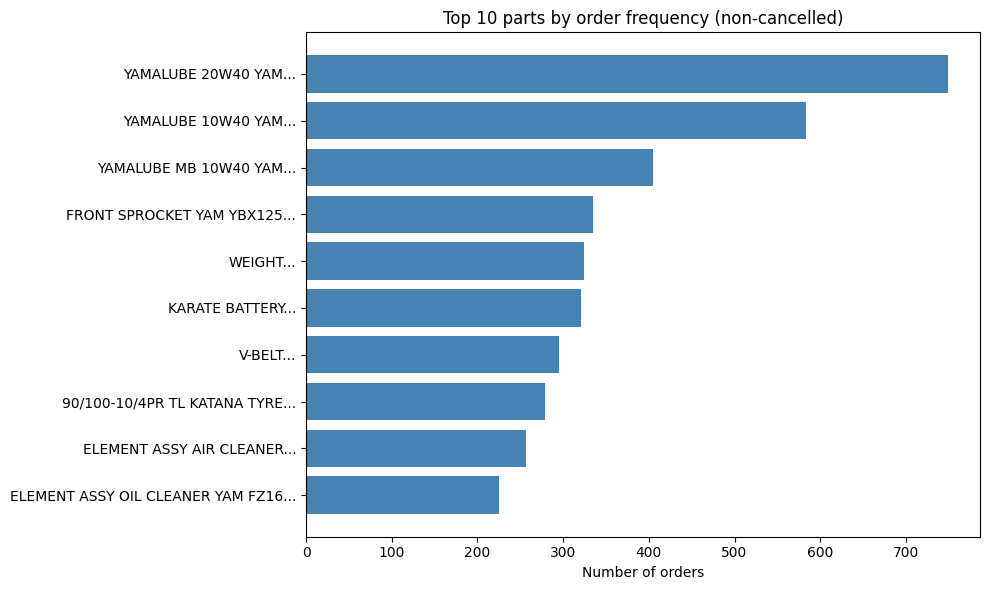

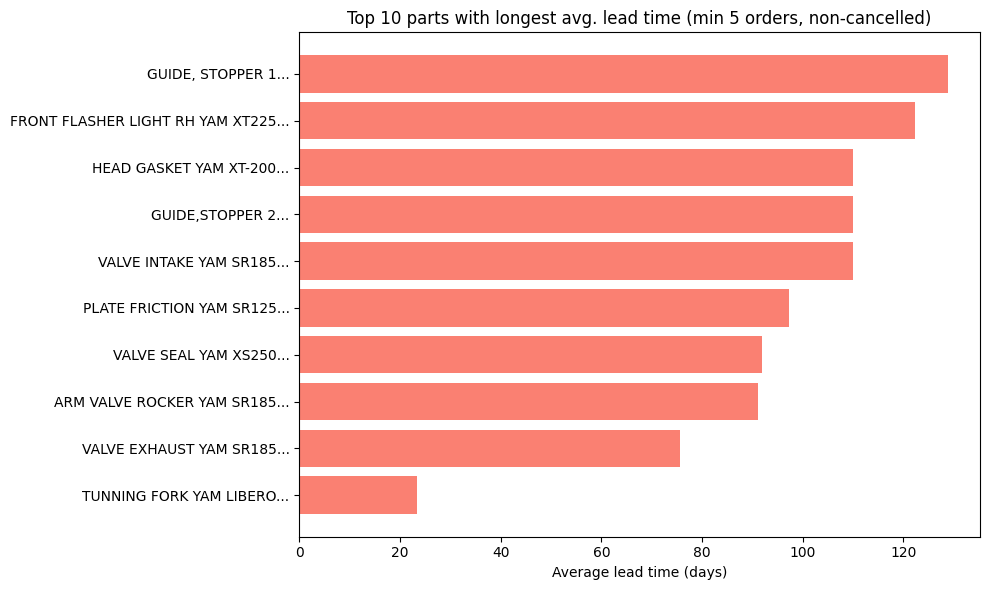

<Figure size 1000x600 with 0 Axes>

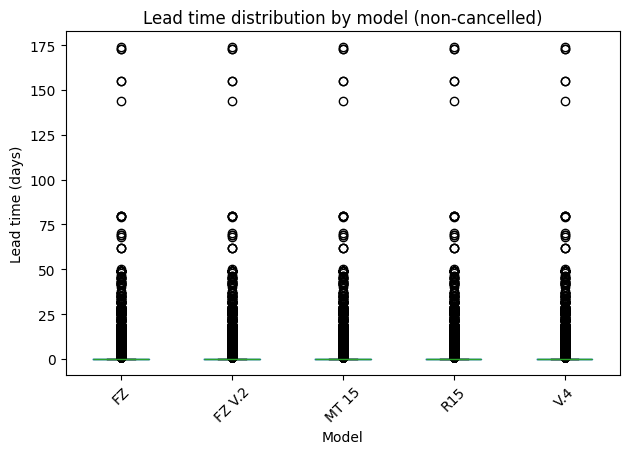

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ----- 0. Ensure 'Is Cancelled' column exists -----
orders_df['Is Cancelled'] = orders_df['Rejection Reason Description'].notna() & (orders_df['Rejection Reason Description'] != '')

# ----- 1. Filter to non‑cancelled orders only -----
non_cancelled = orders_df[orders_df['Is Cancelled'] == False].copy()

# ----- 2. Load the SSOP file -----
ssop_df = pd.read_excel("SSOP.xlsx")
print(ssop_df.columns.tolist())  # optional

# ----- 3. Prepare a clean part number column in SSOP -----
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Description', 'Compatible models']].copy()
ssop_clean = ssop_clean.drop_duplicates(subset='PartNumber')

# ----- 4. Merge with non‑cancelled orders -----
non_cancelled['Material'] = non_cancelled['Material'].astype(str).str.strip()
merged_df = non_cancelled.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# ----- 5. Part‑wise lead time statistics (non‑cancelled only) -----
part_stats = merged_df[merged_df['Lead Time'].notna()].copy()

part_summary = part_stats.groupby('Material').agg(
    part_description=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lead Time', 'count'),
    positive_orders=('Lead Time', lambda x: (x > 0).sum()),
    min_lead=('Lead Time', 'min'),
    max_lead=('Lead Time', 'max'),
    avg_lead=('Lead Time', 'mean'),
    median_lead=('Lead Time', 'median')
).reset_index()

part_summary['avg_lead'] = part_summary['avg_lead'].round(1)
part_summary['median_lead'] = part_summary['median_lead'].round(1)
part_summary['positive_pct'] = (part_summary['positive_orders'] / part_summary['total_orders'] * 100).round(1)

part_summary = part_summary.sort_values('total_orders', ascending=False)
print("\nPart lead time summary (non‑cancelled orders):")
print(part_summary.head(20).to_string())
part_summary.to_csv('part_lead_time_with_models_non_cancelled.csv', index=False)

# ----- 6. Model‑wise lead time statistics -----
model_df = part_stats.copy()
model_df['models_list'] = model_df['Compatible models'].str.split(',')
model_exploded = model_df.explode('models_list')
model_exploded['models_list'] = model_exploded['models_list'].str.strip()
model_exploded = model_exploded[model_exploded['models_list'].notna() & (model_exploded['models_list'] != '')]

model_stats = model_exploded.groupby('models_list')['Lead Time'].agg(
    total_orders='count',
    avg_lead='mean',
    median_lead='median',
    min_lead='min',
    max_lead='max'
).reset_index().sort_values('total_orders', ascending=False)

model_stats['avg_lead'] = model_stats['avg_lead'].round(1)
model_stats['median_lead'] = model_stats['median_lead'].round(1)

print("\nModel‑wise lead time summary (non‑cancelled orders):")
print(model_stats.head(10).to_string())
model_stats.to_csv('model_lead_time_summary_non_cancelled.csv', index=False)

# ----- 7. Visualisations (same as original) -----
# Top 10 parts by order frequency
top_parts = part_summary.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top_parts)), top_parts['total_orders'].values, color='steelblue')
plt.yticks(range(len(top_parts)), top_parts['part_description'].str[:40] + '...')
plt.xlabel('Number of orders')
plt.title('Top 10 parts by order frequency (non‑cancelled)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 parts with longest average lead time (min 5 orders)
freq_parts = part_summary[part_summary['total_orders'] >= 5].copy()
long_lead = freq_parts.nlargest(10, 'avg_lead')
plt.figure(figsize=(10,6))
plt.barh(range(len(long_lead)), long_lead['avg_lead'].values, color='salmon')
plt.yticks(range(len(long_lead)), long_lead['part_description'].str[:40] + '...')
plt.xlabel('Average lead time (days)')
plt.title('Top 10 parts with longest avg. lead time (min 5 orders, non‑cancelled)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Boxplot for top 5 models
top_models = model_stats.head(5)['models_list'].tolist()
model_subset = model_exploded[model_exploded['models_list'].isin(top_models)]
plt.figure(figsize=(10,6))
model_subset.boxplot(column='Lead Time', by='models_list', grid=False)
plt.title('Lead time distribution by model (non‑cancelled)')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Lead time (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analysis for ALL ORDERS
Total lost quantity: 149,162
Average lost quantity per order: 2.84
Orders with lost quantity (>0): 15708
Orders with over‑delivery (<0): 0

Top 10 parts by total lost quantity:
       Material                          part_desc                      models  total_orders  total_lost  avg_lost  max_lost
   1GC-E7632-01                             WEIGHT Ray ZR,Ray ZR Street Rallay           441      5836.0     13.23     350.0
   21C-E3440-01           ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           198      5288.0     26.71     300.0
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      4978.0     62.22    1000.0
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            48      4958.0    103.29    1000.0
21C-E3440-01-00  ELEMENT ASSY OIL CLEANER YAM FZ16                     Unknown           336      4890.0     14.55     200.0
    94701-00254                PLUG, SPARK (C7HS

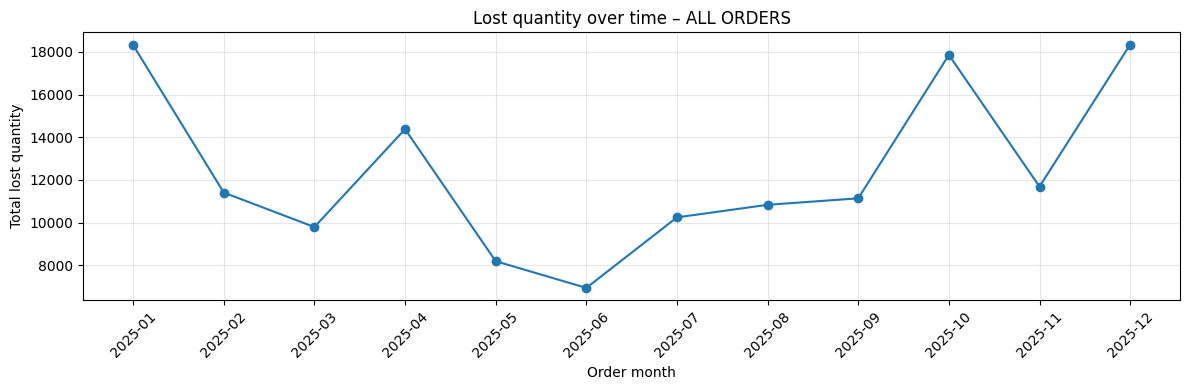

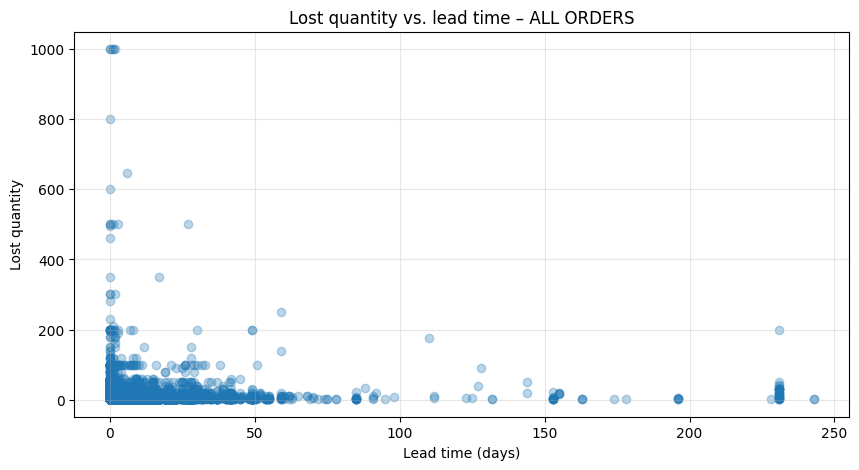


Analysis for NON‑CANCELLED ORDERS
Total lost quantity: 42,815
Average lost quantity per order: 1.16
Orders with lost quantity (>0): 4744
Orders with over‑delivery (<0): 0

Top 10 parts by total lost quantity:
       Material                          part_desc                      models  total_orders  total_lost  avg_lost  max_lost
   21C-E3440-01           ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           147      3455.0     23.50     200.0
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            60      2148.0     35.80    1000.0
   1GC-E7632-01                             WEIGHT Ray ZR,Ray ZR Street Rallay           324      1935.0      5.97     280.0
   1GC-E2119-00                   SEAL, VALVE STEM Ray ZR,Ray ZR Street Rallay           125      1439.0     11.51     100.0
    94701-00254                PLUG, SPARK (C7HSA)                      COMMON           170      1258.0      7.40     200.0
21C-E3440-01-00  ELEMENT ASSY OIL CLEANE

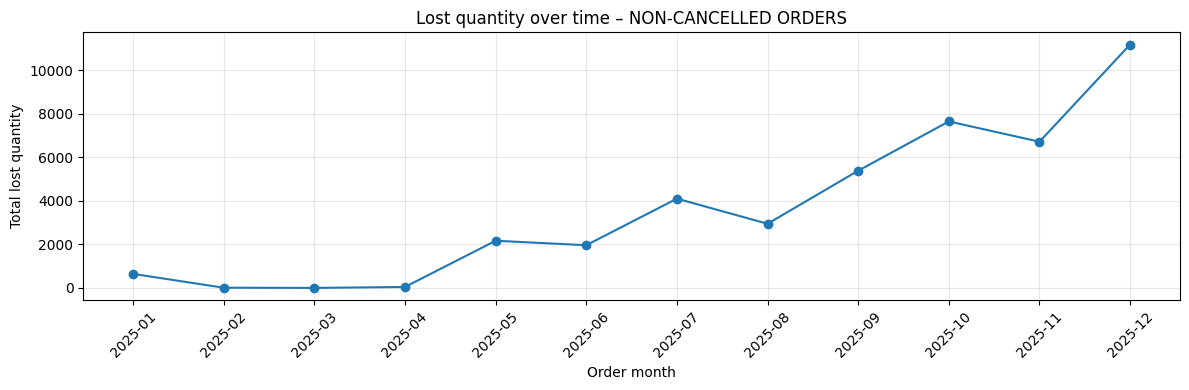

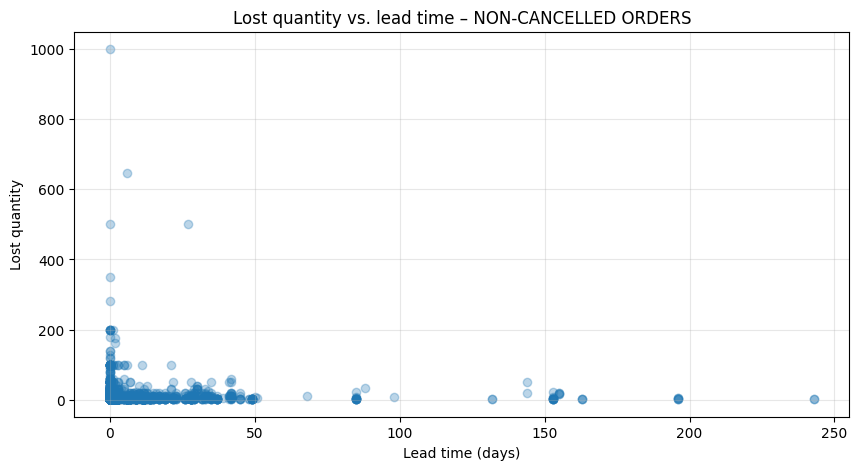


Analysis for CANCELLED ORDERS
Total lost quantity: 106,347
Average lost quantity per order: 6.85
Orders with lost quantity (>0): 10964
Orders with over‑delivery (<0): 0

Top 10 parts by total lost quantity:
       Material                          part_desc                      models  total_orders  total_lost  avg_lost  max_lost
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            20      4958.0    247.90    1000.0
21C-E3440-01-00  ELEMENT ASSY OIL CLEANER YAM FZ16                     Unknown           111      3968.0     35.75     200.0
   1GC-E7632-01                             WEIGHT Ray ZR,Ray ZR Street Rallay           117      3901.0     33.34     350.0
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            20      2830.0    141.50    1000.0
1GC-E4450-00-00 ELEMENT ASSY,AIR CLEANER YAM XC115                     Unknown           148      2514.0     16.99     100.0
    94703-00885  SPARK PLUG (NGK CPR8EA-R9

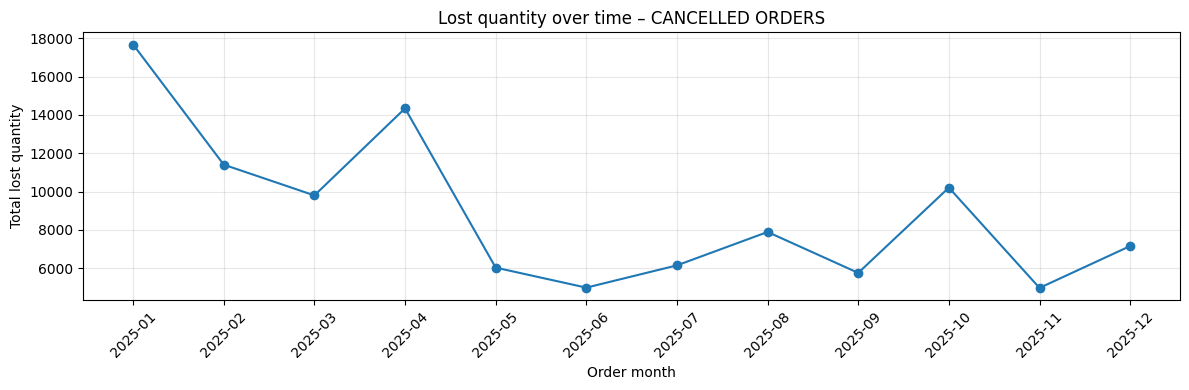

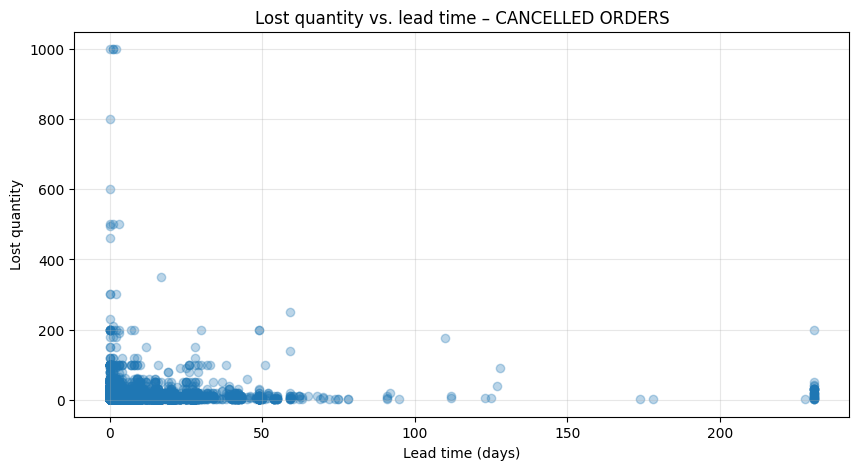

In [25]:
# Load SSOP and prepare part number
ssop_df = pd.read_excel('SSOP.xlsx')
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Compatible models']].drop_duplicates(subset='PartNumber')

# Merge with orders
orders_df['Material'] = orders_df['Material'].astype(str).str.strip()
merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

def analyze_lost_qty(df, group_name):
    print(f"\n{'='*60}")
    print(f"Analysis for {group_name}")
    print('='*60)

    # Basic stats
    total_lost = df['Lost Qty'].sum()
    avg_lost = df['Lost Qty'].mean()
    orders_with_loss = (df['Lost Qty'] > 0).sum()
    orders_with_over = (df['Lost Qty'] < 0).sum()

    print(f"Total lost quantity: {total_lost:,.0f}")
    print(f"Average lost quantity per order: {avg_lost:.2f}")
    print(f"Orders with lost quantity (>0): {orders_with_loss}")
    print(f"Orders with over‑delivery (<0): {orders_with_over}")

    # Top parts by total lost
    part_lost = df.groupby('Material').agg(
        part_desc=('Material Description', 'first'),
        models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
        total_orders=('Lost Qty', 'count'),
        total_lost=('Lost Qty', 'sum'),
        avg_lost=('Lost Qty', 'mean'),
        max_lost=('Lost Qty', 'max')
    ).reset_index().sort_values('total_lost', ascending=False)
    part_lost['avg_lost'] = part_lost['avg_lost'].round(2)

    print("\nTop 10 parts by total lost quantity:")
    print(part_lost.head(10).to_string(index=False))

    # Top customers
    cust_lost = df.groupby('Sold-To Party Name').agg(
        total_orders=('Lost Qty', 'count'),
        total_lost=('Lost Qty', 'sum'),
        avg_lost=('Lost Qty', 'mean')
    ).reset_index().sort_values('total_lost', ascending=False)
    print("\nTop 10 customers by total lost quantity:")
    print(cust_lost.head(10).to_string(index=False))

    # Model‑wise lost (exploded)
    model_df = df.copy()
    model_df['models'] = model_df['Compatible models'].str.split(',')
    model_exploded = model_df.explode('models')
    model_exploded['models'] = model_exploded['models'].str.strip()
    model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

    model_lost = model_exploded.groupby('models').agg(
        total_orders=('Lost Qty', 'count'),
        total_lost=('Lost Qty', 'sum'),
        avg_lost=('Lost Qty', 'mean')
    ).reset_index().sort_values('total_lost', ascending=False)
    print("\nTop 10 models by total lost quantity:")
    print(model_lost.head(10).to_string(index=False))

    # Time trend (monthly)
    df['Order Month'] = df['Created On'].dt.to_period('M')
    monthly_lost = df.groupby('Order Month')['Lost Qty'].sum().reset_index()
    monthly_lost['Order Month'] = monthly_lost['Order Month'].astype(str)

    plt.figure(figsize=(12,4))
    plt.plot(monthly_lost['Order Month'], monthly_lost['Lost Qty'], marker='o')
    plt.xlabel('Order month')
    plt.ylabel('Total lost quantity')
    plt.title(f'Lost quantity over time – {group_name}')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Scatter: lost vs lead time (positive lost only)
    pos_lost = df[df['Lost Qty'] > 0].copy()
    if len(pos_lost) > 0:
        plt.figure(figsize=(10,5))
        plt.scatter(pos_lost['Lead Time'], pos_lost['Lost Qty'], alpha=0.3)
        plt.xlabel('Lead time (days)')
        plt.ylabel('Lost quantity')
        plt.title(f'Lost quantity vs. lead time – {group_name}')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No positive lost orders to plot.")

    return part_lost, cust_lost, model_lost

   # All orders
all_results = analyze_lost_qty(merged_df, "ALL ORDERS")

# Non‑cancelled
non_cancelled = merged_df[merged_df['Is Cancelled'] == False].copy()
non_cancelled_results = analyze_lost_qty(non_cancelled, "NON‑CANCELLED ORDERS")

# Cancelled
cancelled = merged_df[merged_df['Is Cancelled'] == True].copy()
cancelled_results = analyze_lost_qty(cancelled, "CANCELLED ORDERS")

#all_results[0].to_csv('lost_qty_all_parts.csv', index=False)
#all_results[1].to_csv('lost_qty_all_customers.csv', index=False)
#all_results[2].to_csv('lost_qty_all_models.csv', index=False)

#non_cancelled_results[0].to_csv('lost_qty_non_cancelled_parts.csv', index=False)
#non_cancelled_results[1].to_csv('lost_qty_non_cancelled_customers.csv', index=False)
#non_cancelled_results[2].to_csv('lost_qty_non_cancelled_models.csv', index=False)

#cancelled_results[0].to_csv('lost_qty_cancelled_parts.csv', index=False)
#cancelled_results[1].to_csv('lost_qty_cancelled_customers.csv', index=False)
#cancelled_results[2].to_csv('lost_qty_cancelled_models.csv', index=False)


Lost Sales Analysis – ALL ORDERS

Total lost sales value: 151,998,872.67 LKR
Average lost sales per order: 2,897.81 LKR
Orders with positive lost sales: 15660
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                          part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
1GC-WE661-10-00                CYLINDER PISTON KIT                     Unknown            77      2.634203e+06        34210.42
   2RB-14940-00                     DIAPHRAGM ASSY Ray ZR,Ray ZR Street Rallay           201      2.453050e+06        12204.23
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      2.374506e+06        29681.32
      571902NAE                 YAMALUBE 10W40 YAM                     Unknown           688      2.252989e+06         3274.69
   4EB-23145-01                  OIL SEAL YAM FZ16   FZ V.2,MT 15,FZ,V.4, R15,           165      2.226525e+06        1

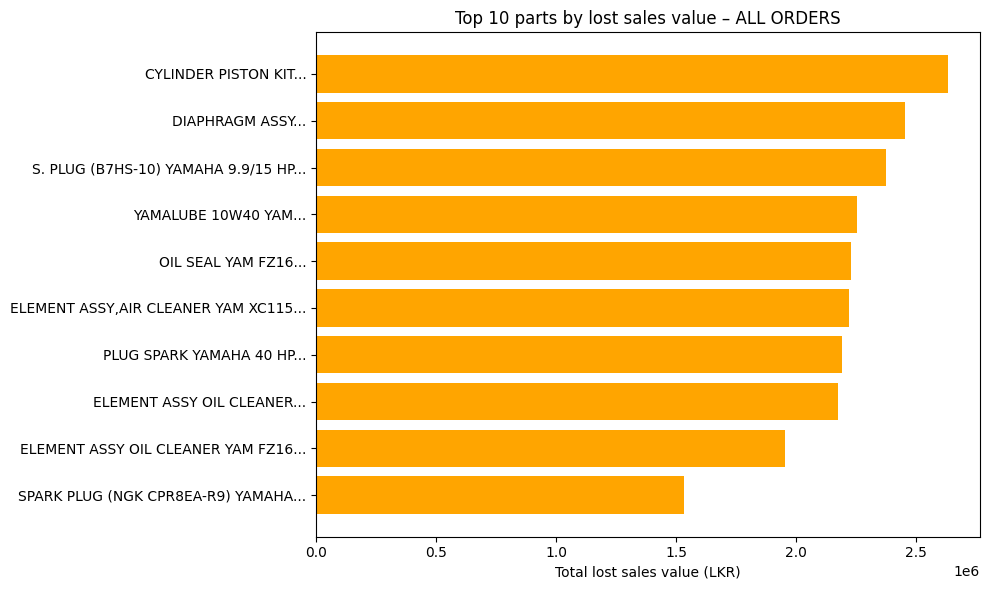


Top 10 customers by total lost sales value:
                   Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
               Union Auto Enterprises          3059      8.419668e+06     2752.425045
Fernando Auto House (private) Limited            35      5.554906e+06   158711.610371
                      Azhakan Traders           339      3.784184e+06    11162.785939
                    Wijesinghe Motors           432      3.638983e+06     8423.572885
             New Chilaw Yamaha Center           524      3.619324e+06     6907.106471
                    New Indika Motors           332      3.261839e+06     9824.815384
                Wasantha Motors Galle           676      3.244583e+06     4799.678411
                           Chen Koong           611      2.773076e+06     4538.586412
  Chandima Enterprises - Nikaweratiya           625      2.722570e+06     4356.111532
                        Windom Motors           605      2.570576e+06     4248.885271


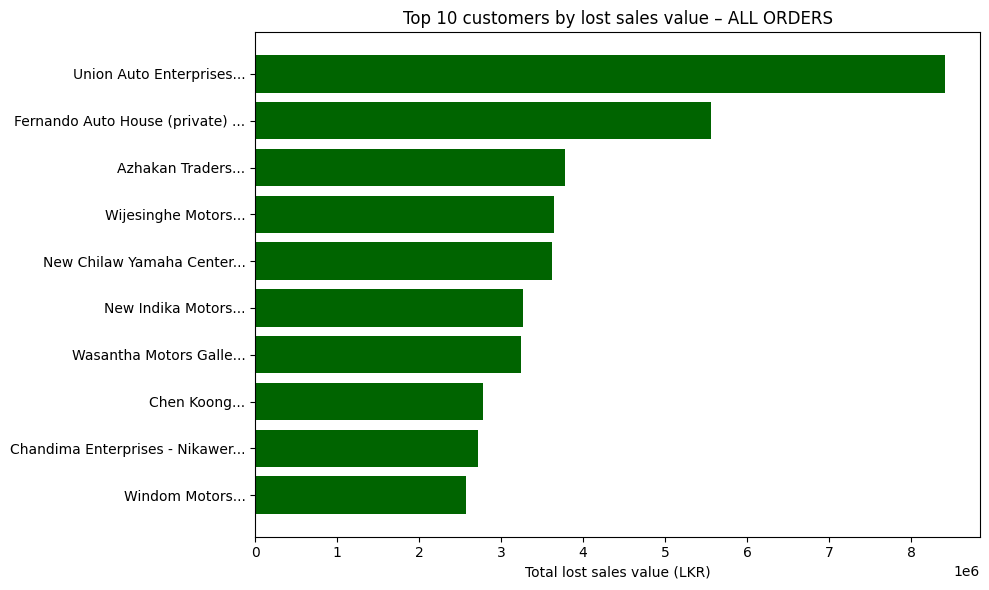


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ         10370      2.835518e+07     2734.347024
              FZ V.2         10370      2.835518e+07     2734.347024
               MT 15         10370      2.835518e+07     2734.347024
                 R15         10370      2.835518e+07     2734.347024
                 V.4         10370      2.835518e+07     2734.347024
              Ray ZR          7071      1.813051e+07     2564.066025
Ray ZR Street Rallay          7071      1.813051e+07     2564.066025
              COMMON           856      3.502136e+06     4091.280081


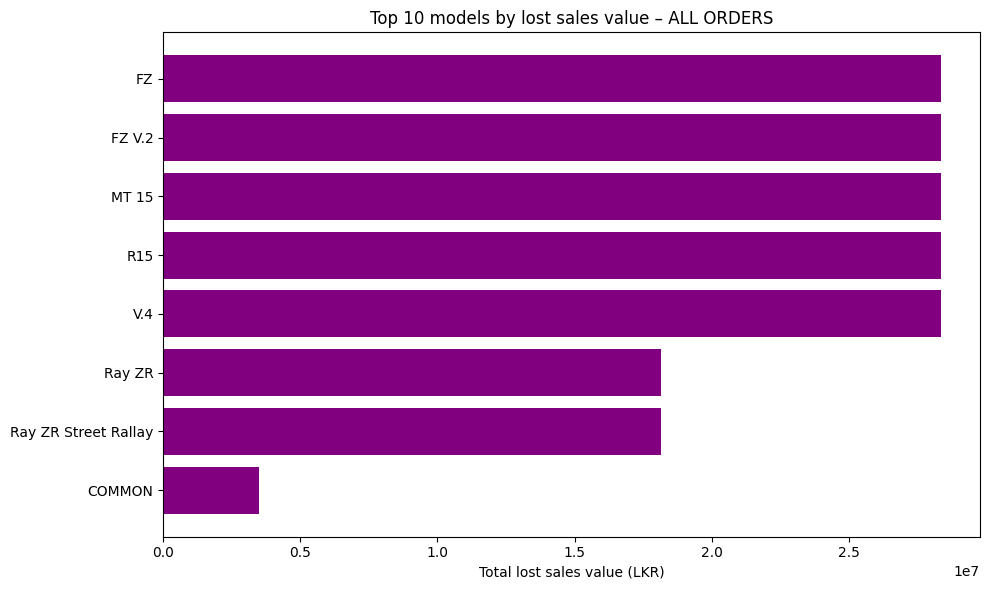

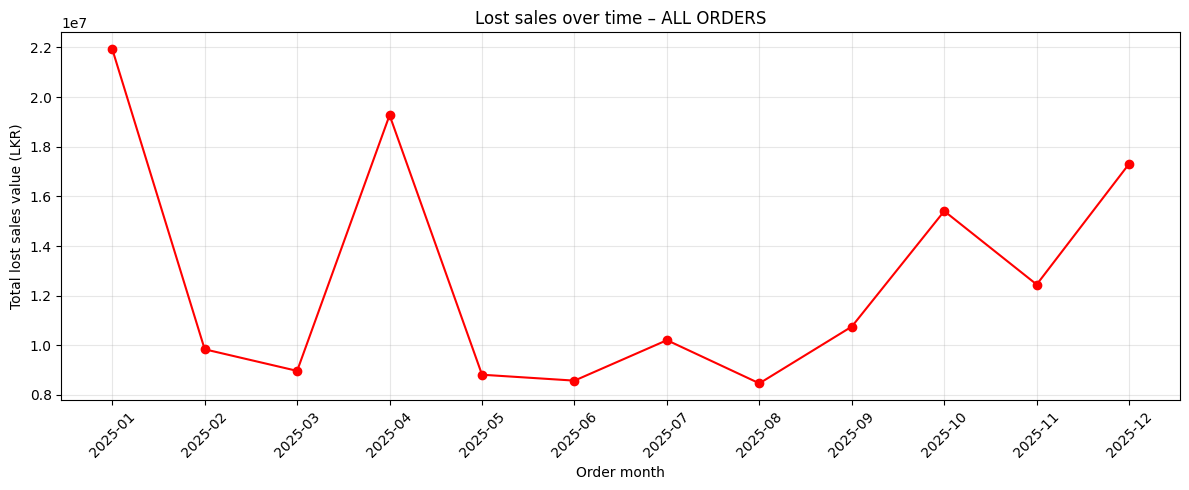

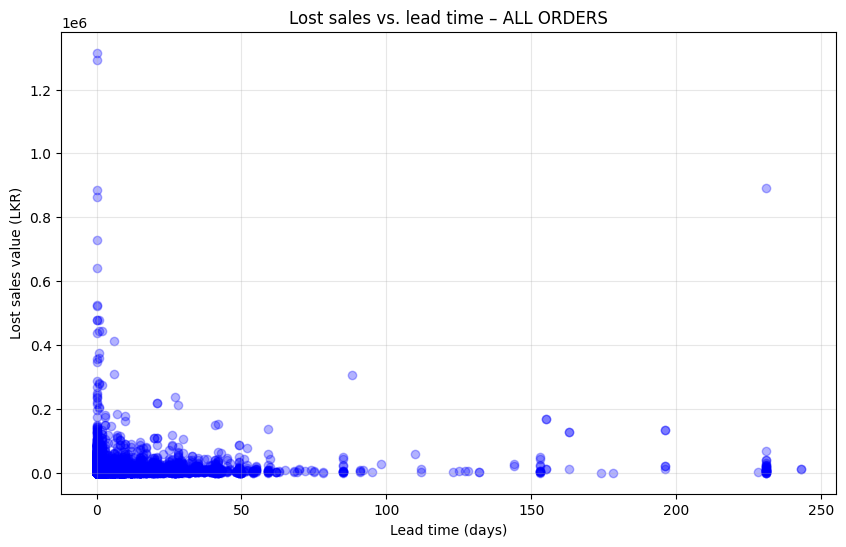


Lost Sales Analysis – NON‑CANCELLED ORDERS

Total lost sales value: 43,116,011.58 LKR
Average lost sales per order: 1,167.32 LKR
Orders with positive lost sales: 4743
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                             part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
   21C-E3440-01              ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           147       1427390.005         9710.14
    94702-00217    S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            60       1024596.000        17076.60
99000-22B63-046       SUZUKI CVT FLUID (GREEN II 4 L)                     Unknown             1        884400.000       884400.00
   2RB-14940-00                        DIAPHRAGM ASSY Ray ZR,Ray ZR Street Rallay           110        698389.510         6349.00
   B62-F5190-00                        GEAR UNIT ASSY Ray ZR,Ray ZR Street Rallay           105 

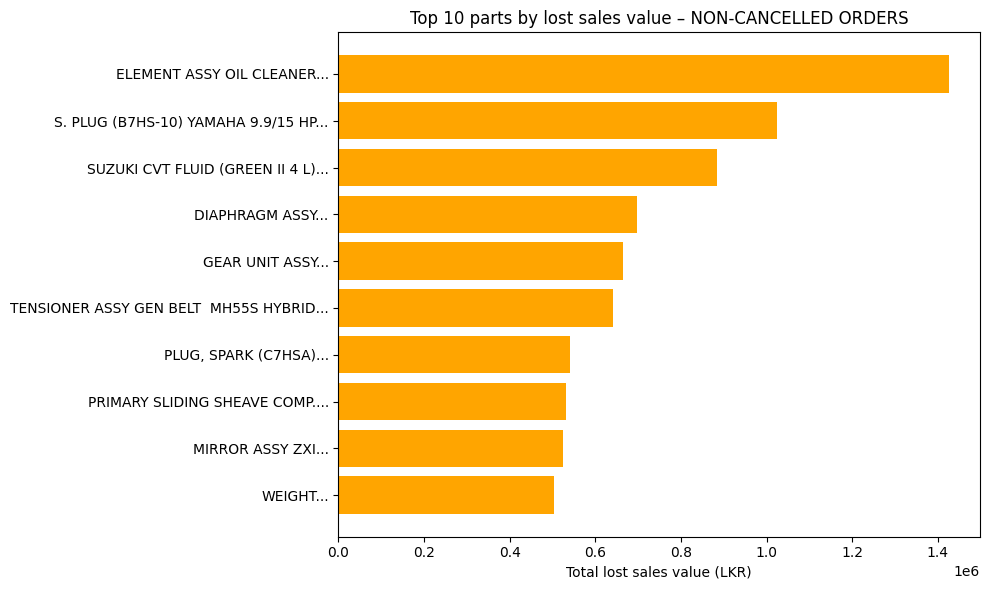


Top 10 customers by total lost sales value:
         Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
          Wijesinghe Motors           337      1.968298e+06     5840.646464
      Wasantha Motors Galle           521      1.740259e+06     3340.227497
           Green Auto Lanka             8      1.725015e+06   215626.848750
Jaffna Automobile (pvt) Ltd            34      1.264597e+06    37194.015294
             Modern  Motors           451      1.237237e+06     2743.320021
       Manju Service Center           514      1.225823e+06     2384.870142
       Nalinda Super Motors           206      9.411912e+05     4568.889265
               Union Motors           288      8.533336e+05     2962.963889
              Samagi Motors           462      8.075344e+05     1747.910031
         Mahesh Enterprises           215      7.139782e+05     3320.828768


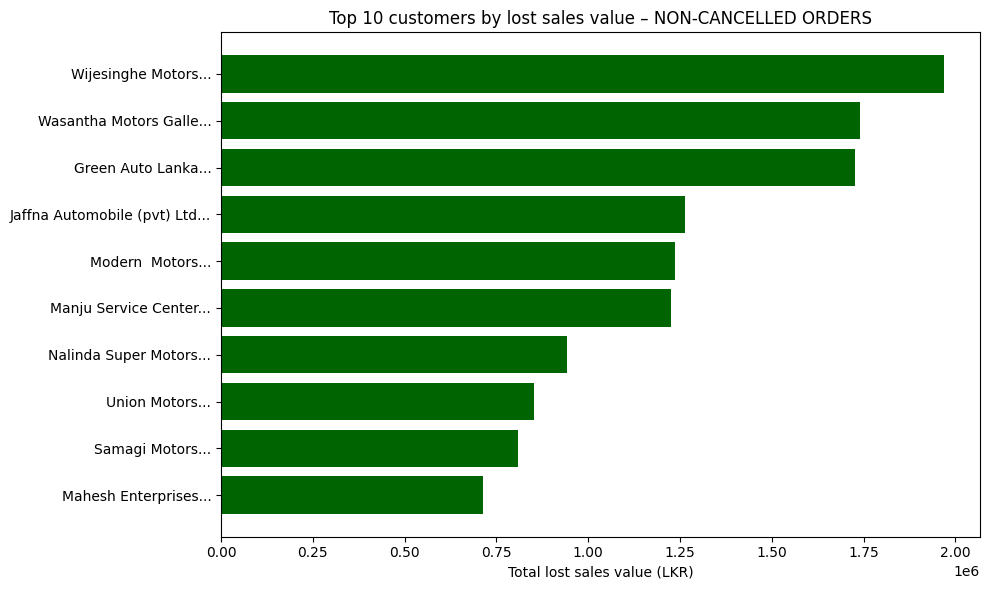


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ          7041      8.378154e+06     1189.909732
              FZ V.2          7041      8.378154e+06     1189.909732
               MT 15          7041      8.378154e+06     1189.909732
                 R15          7041      8.378154e+06     1189.909732
                 V.4          7041      8.378154e+06     1189.909732
              Ray ZR          4740      7.129667e+06     1504.149181
Ray ZR Street Rallay          4740      7.129667e+06     1504.149181
              COMMON           539      1.258901e+06     2335.622720


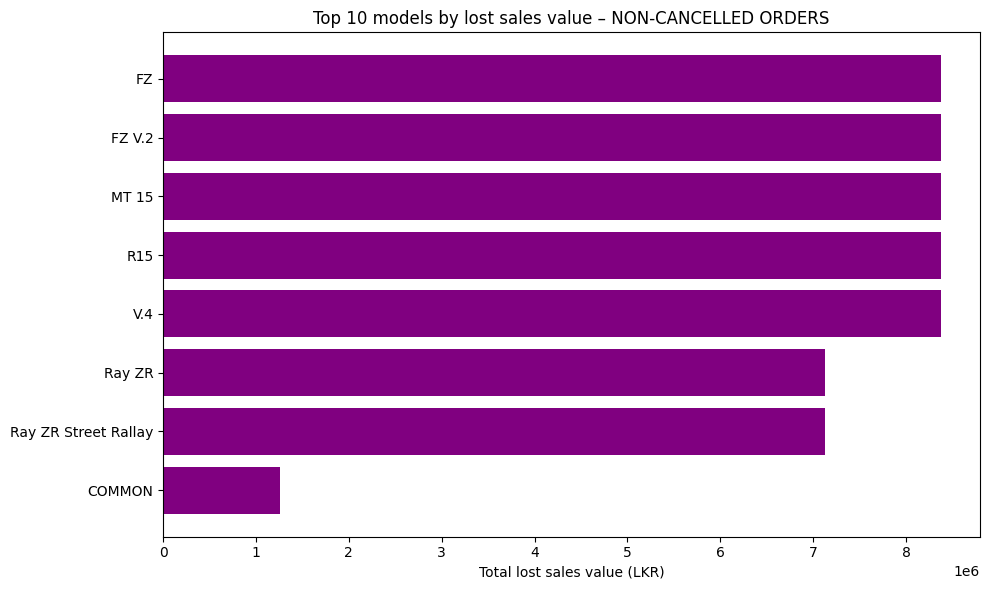

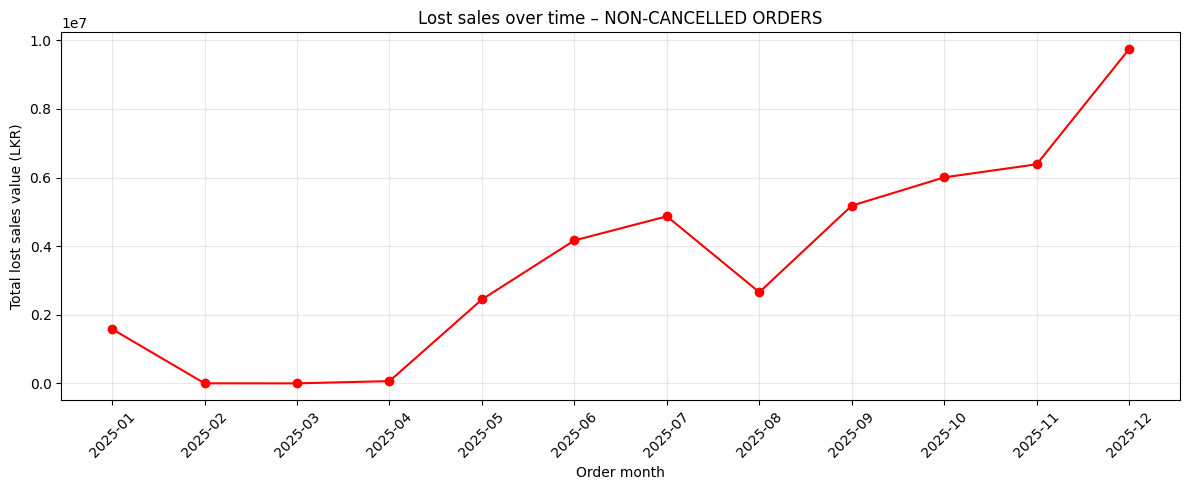

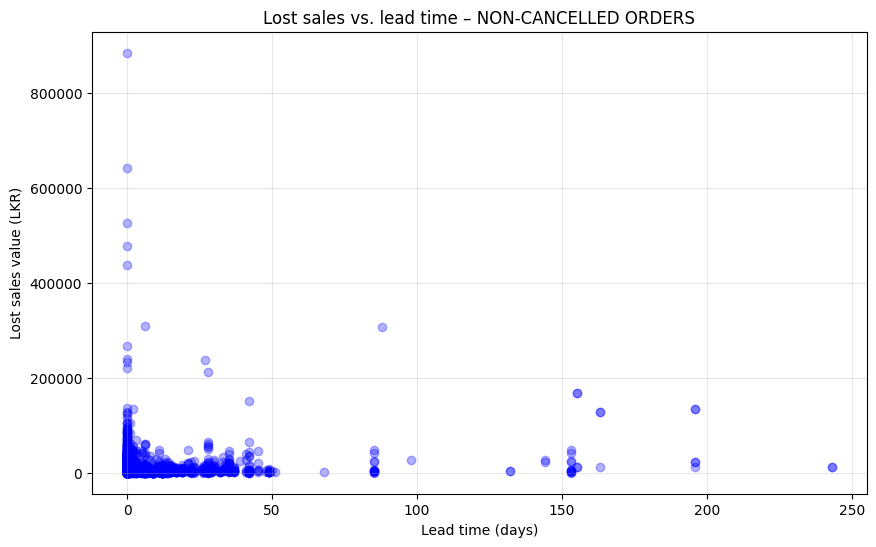


Lost Sales Analysis – CANCELLED ORDERS

Total lost sales value: 108,882,861.09 LKR
Average lost sales per order: 7,017.00 LKR
Orders with positive lost sales: 10917
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                          part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
1GC-WE661-10-00                CYLINDER PISTON KIT                     Unknown            18      2.434678e+06       135259.86
   4EB-23145-01                  OIL SEAL YAM FZ16   FZ V.2,MT 15,FZ,V.4, R15,            83      2.197847e+06        26480.08
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            20      2.189488e+06       109474.42
1GC-E4450-00-00 ELEMENT ASSY,AIR CLEANER YAM XC115                     Unknown           148      2.092670e+06        14139.66
      571902NAE                 YAMALUBE 10W40 YAM                     Unknown           105      2.008375e+06   

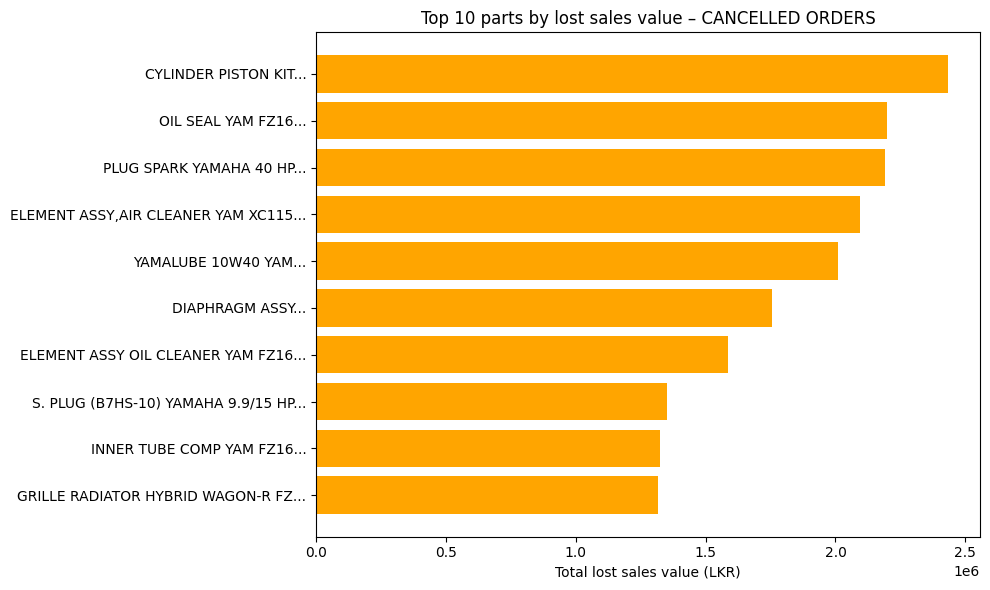


Top 10 customers by total lost sales value:
                   Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
               Union Auto Enterprises          2046      8.419668e+06     4115.184855
Fernando Auto House (private) Limited            35      5.554906e+06   158711.610371
                      Azhakan Traders           138      3.775413e+06    27358.067126
             New Chilaw Yamaha Center           154      3.466406e+06    22509.132407
                    New Indika Motors           189      3.148180e+06    16657.039342
                           Chen Koong           287      2.369578e+06     8256.370650
                  Digital Electronics           310      2.243043e+06     7235.622676
                        Windom Motors           263      2.224881e+06     8459.624915
  Chandima Enterprises - Nikaweratiya           198      2.086999e+06    10540.400627
          Rathnasiri Motorcycle Works           268      1.957470e+06     7303.993681


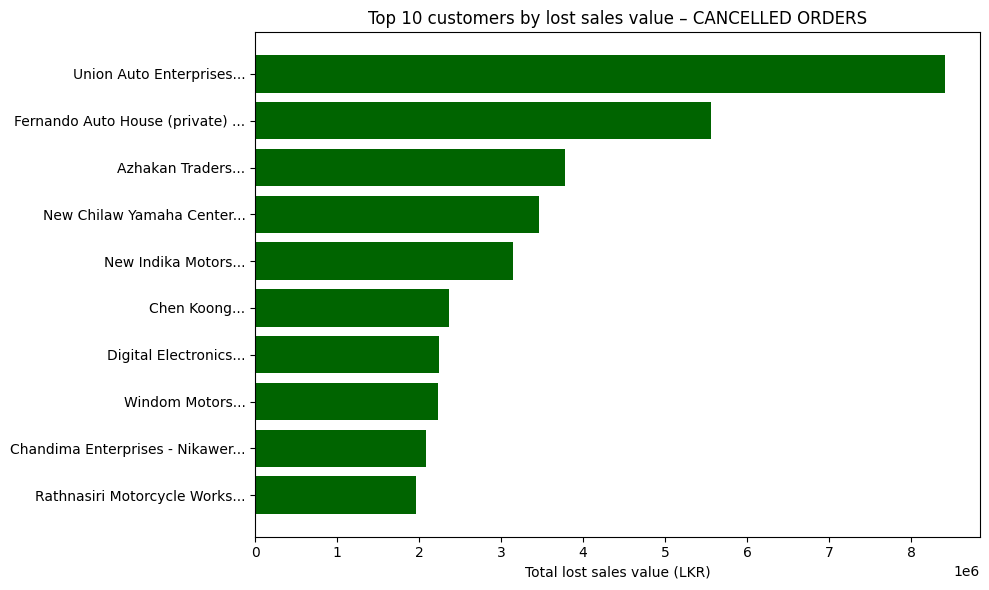


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ          3329      1.997702e+07     6000.908445
              FZ V.2          3329      1.997702e+07     6000.908445
               MT 15          3329      1.997702e+07     6000.908445
                 R15          3329      1.997702e+07     6000.908445
                 V.4          3329      1.997702e+07     6000.908445
              Ray ZR          2331      1.100084e+07     4719.366684
Ray ZR Street Rallay          2331      1.100084e+07     4719.366684
              COMMON           317      2.243235e+06     7076.451429


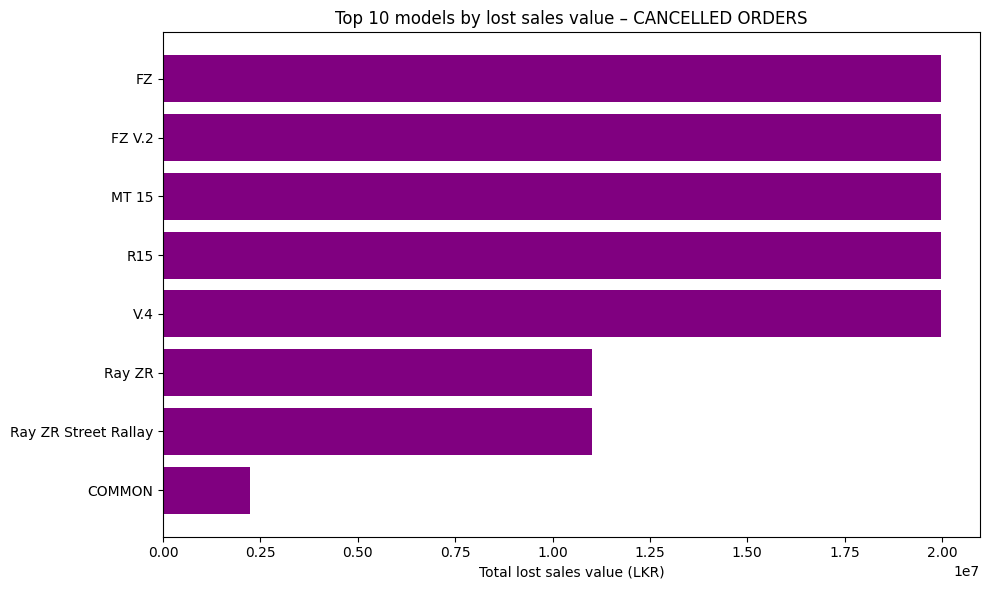

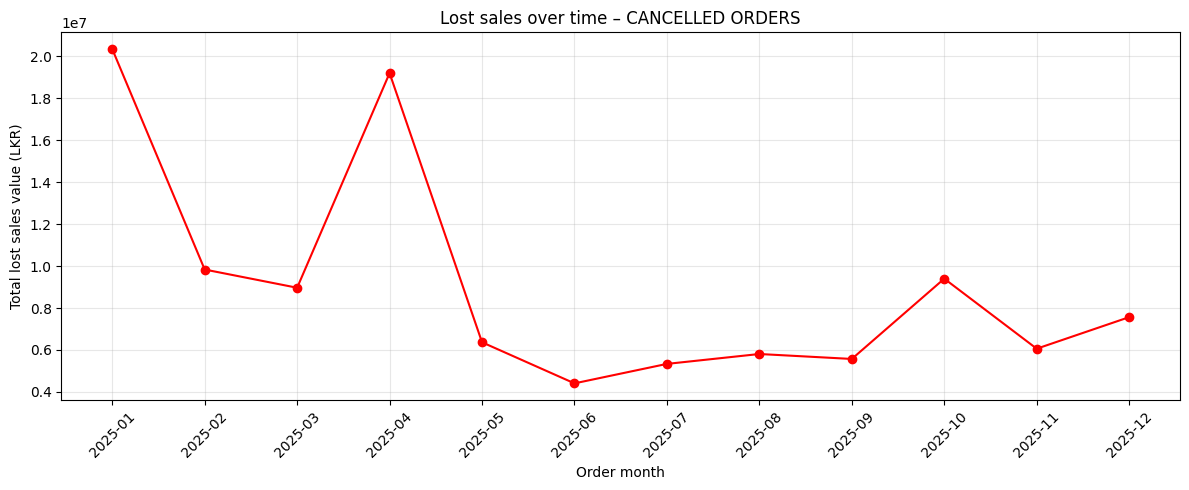

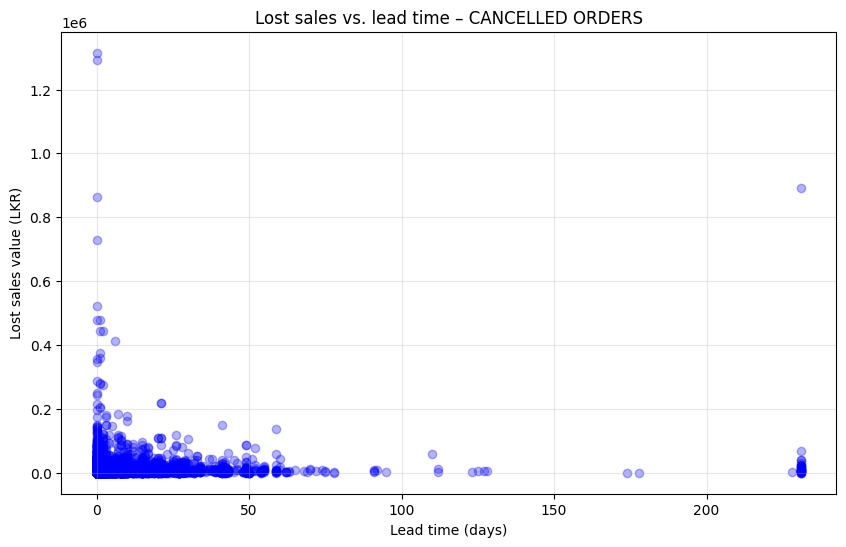

In [26]:
def analyze_lost_sales(df, group_name):
    """
    Perform lost sales analysis on the given DataFrame and print/plot results.
    Returns three DataFrames: part summary, customer summary, model summary.
    """
    print(f"\n{'='*60}")
    print(f"Lost Sales Analysis – {group_name}")
    print('='*60)

    # Avoid division by zero when calculating unit price
    df = df.copy()
    df['Unit Price'] = df.apply(
        lambda row: row['Net Value (Item)'] / row['Order Quantity (Item)']
        if pd.notna(row['Net Value (Item)']) and pd.notna(row['Order Quantity (Item)']) and row['Order Quantity (Item)'] > 0
        else 0,
        axis=1
    )
    df['Lost Sales Value'] = df['Lost Qty'] * df['Unit Price']

    # Basic statistics
    total_lost_sales = df['Lost Sales Value'].sum()
    avg_lost_sales_per_order = df['Lost Sales Value'].mean()
    orders_with_lost_sales = (df['Lost Sales Value'] > 0).sum()
    orders_with_negative_lost = (df['Lost Sales Value'] < 0).sum()   # over‑delivery

    print(f"\nTotal lost sales value: {total_lost_sales:,.2f} LKR")
    print(f"Average lost sales per order: {avg_lost_sales_per_order:,.2f} LKR")
    print(f"Orders with positive lost sales: {orders_with_lost_sales}")
    print(f"Orders with over‑delivery (negative lost): {orders_with_negative_lost}")

    # ---- Part‑wise lost sales ----
    part_lost_sales = df.groupby('Material').agg(
        part_desc=('Material Description', 'first'),
        models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)

    part_lost_sales['avg_lost_sales'] = part_lost_sales['avg_lost_sales'].round(2)

    print("\nTop 10 parts by total lost sales value:")
    print(part_lost_sales.head(10).to_string(index=False))

    # Bar chart – top 10 parts
    top10_parts = part_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_parts)), top10_parts['total_lost_sales'].values, color='orange')
    plt.yticks(range(len(top10_parts)), top10_parts['part_desc'].str[:40] + '...')
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 parts by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Customer‑wise lost sales ----
    cust_lost_sales = df.groupby('Sold-To Party Name').agg(
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)

    print("\nTop 10 customers by total lost sales value:")
    print(cust_lost_sales.head(10).to_string(index=False))

    top10_cust = cust_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_cust)), top10_cust['total_lost_sales'].values, color='darkgreen')
    plt.yticks(range(len(top10_cust)), top10_cust['Sold-To Party Name'].str[:30] + '...')
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 customers by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Model‑wise lost sales (exploded) ----
    model_df = df.copy()
    model_df['models'] = model_df['Compatible models'].str.split(',')
    model_exploded = model_df.explode('models')
    model_exploded['models'] = model_exploded['models'].str.strip()
    model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

    model_lost_sales = model_exploded.groupby('models').agg(
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)

    print("\nTop 10 models by total lost sales value:")
    print(model_lost_sales.head(10).to_string(index=False))

    top10_models = model_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_models)), top10_models['total_lost_sales'].values, color='purple')
    plt.yticks(range(len(top10_models)), top10_models['models'])
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 models by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Time trend ----
    df['Order Month'] = df['Created On'].dt.to_period('M')
    monthly_lost_sales = df.groupby('Order Month')['Lost Sales Value'].sum().reset_index()
    monthly_lost_sales['Order Month'] = monthly_lost_sales['Order Month'].astype(str)

    plt.figure(figsize=(12,5))
    plt.plot(monthly_lost_sales['Order Month'], monthly_lost_sales['Lost Sales Value'], marker='o', color='red')
    plt.xlabel('Order month')
    plt.ylabel('Total lost sales value (LKR)')
    plt.title(f'Lost sales over time – {group_name}')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- Lost sales vs. lead time (positive loss only) ----
    pos_lost_sales = df[df['Lost Sales Value'] > 0].copy()
    if len(pos_lost_sales) > 0:
        plt.figure(figsize=(10,6))
        plt.scatter(pos_lost_sales['Lead Time'], pos_lost_sales['Lost Sales Value'], alpha=0.3, color='blue')
        plt.xlabel('Lead time (days)')
        plt.ylabel('Lost sales value (LKR)')
        plt.title(f'Lost sales vs. lead time – {group_name}')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No positive lost sales orders to plot.")

    return part_lost_sales, cust_lost_sales, model_lost_sales

### Apply the function to the three groups
# All orders
all_sales = analyze_lost_sales(merged_df, "ALL ORDERS")

# Non‑cancelled
non_cancelled = merged_df[merged_df['Is Cancelled'] == False].copy()
non_cancelled_sales = analyze_lost_sales(non_cancelled, "NON‑CANCELLED ORDERS")

# Cancelled
cancelled = merged_df[merged_df['Is Cancelled'] == True].copy()
cancelled_sales = analyze_lost_sales(cancelled, "CANCELLED ORDERS")

#all_sales[0].to_csv('lost_sales_all_parts.csv', index=False)
#all_sales[1].to_csv('lost_sales_all_customers.csv', index=False)
#all_sales[2].to_csv('lost_sales_all_models.csv', index=False)

#non_cancelled_sales[0].to_csv('lost_sales_non_cancelled_parts.csv', index=False)
#non_cancelled_sales[1].to_csv('lost_sales_non_cancelled_customers.csv', index=False)
#non_cancelled_sales[2].to_csv('lost_sales_non_cancelled_models.csv', index=False)

#cancelled_sales[0].to_csv('lost_sales_cancelled_parts.csv', index=False)
#cancelled_sales[1].to_csv('lost_sales_cancelled_customers.csv', index=False)
#cancelled_sales[2].to_csv('lost_sales_cancelled_models.csv', index=False)


Lost Sales Analysis – ALL ORDERS
Total lost sales value: 151,998,872.67 LKR
Average lost sales per order: 2,897.81 LKR
Orders with positive lost sales: 15660
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                          part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
1GC-WE661-10-00                CYLINDER PISTON KIT                     Unknown            77      2.634203e+06        34210.42
   2RB-14940-00                     DIAPHRAGM ASSY Ray ZR,Ray ZR Street Rallay           201      2.453050e+06        12204.23
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      2.374506e+06        29681.32
      571902NAE                 YAMALUBE 10W40 YAM                     Unknown           688      2.252989e+06         3274.69
   4EB-23145-01                  OIL SEAL YAM FZ16   FZ V.2,MT 15,FZ,V.4, R15,           165      2.226525e+06        13

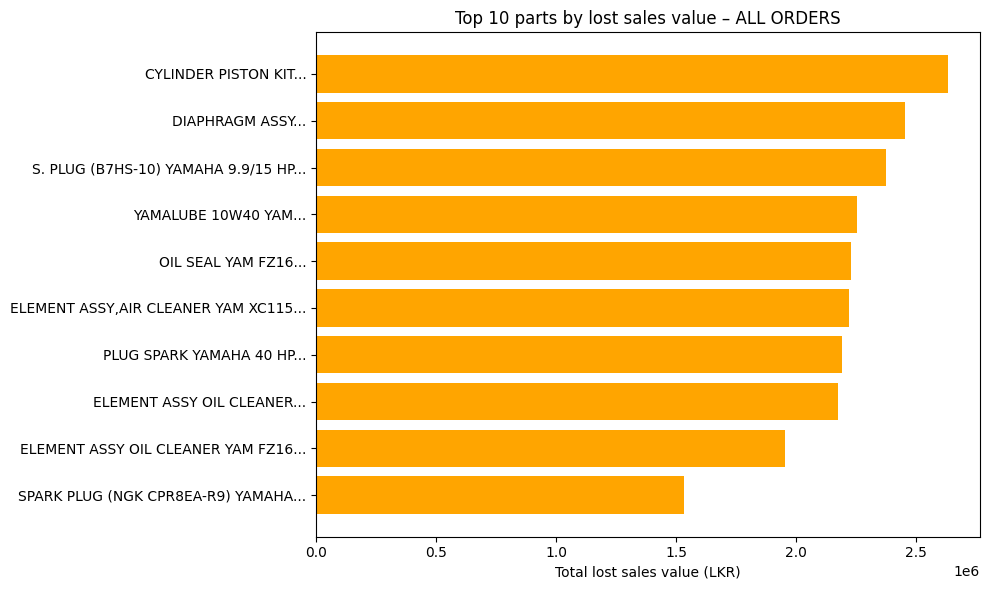


Top 10 customers by total lost sales value:
                   Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
               Union Auto Enterprises          3059      8.419668e+06     2752.425045
Fernando Auto House (private) Limited            35      5.554906e+06   158711.610371
                      Azhakan Traders           339      3.784184e+06    11162.785939
                    Wijesinghe Motors           432      3.638983e+06     8423.572885
             New Chilaw Yamaha Center           524      3.619324e+06     6907.106471
                    New Indika Motors           332      3.261839e+06     9824.815384
                Wasantha Motors Galle           676      3.244583e+06     4799.678411
                           Chen Koong           611      2.773076e+06     4538.586412
  Chandima Enterprises - Nikaweratiya           625      2.722570e+06     4356.111532
                        Windom Motors           605      2.570576e+06     4248.885271


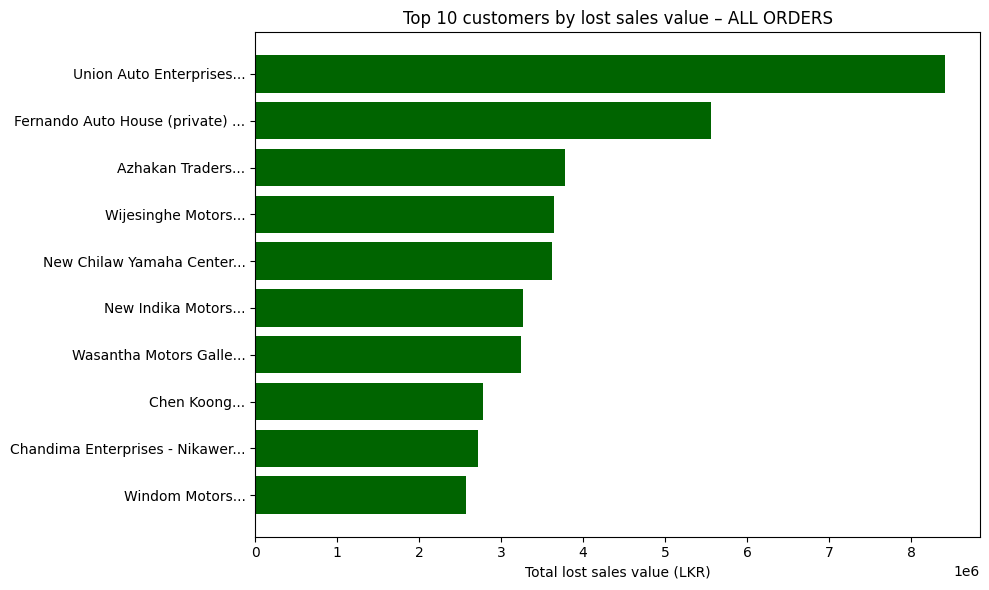


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ         10370      2.835518e+07     2734.347024
              FZ V.2         10370      2.835518e+07     2734.347024
               MT 15         10370      2.835518e+07     2734.347024
                 R15         10370      2.835518e+07     2734.347024
                 V.4         10370      2.835518e+07     2734.347024
              Ray ZR          7071      1.813051e+07     2564.066025
Ray ZR Street Rallay          7071      1.813051e+07     2564.066025
              COMMON           856      3.502136e+06     4091.280081


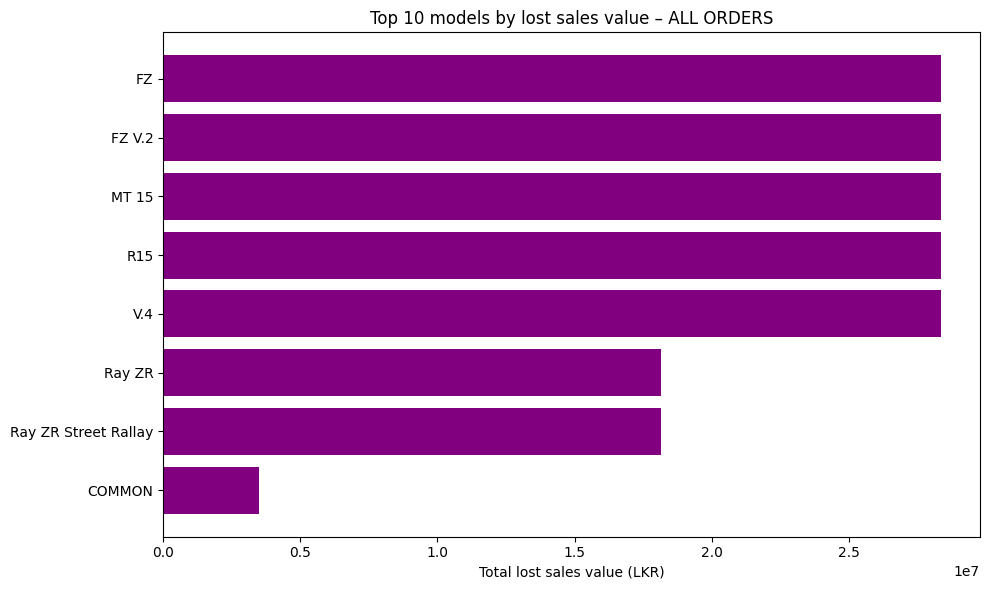

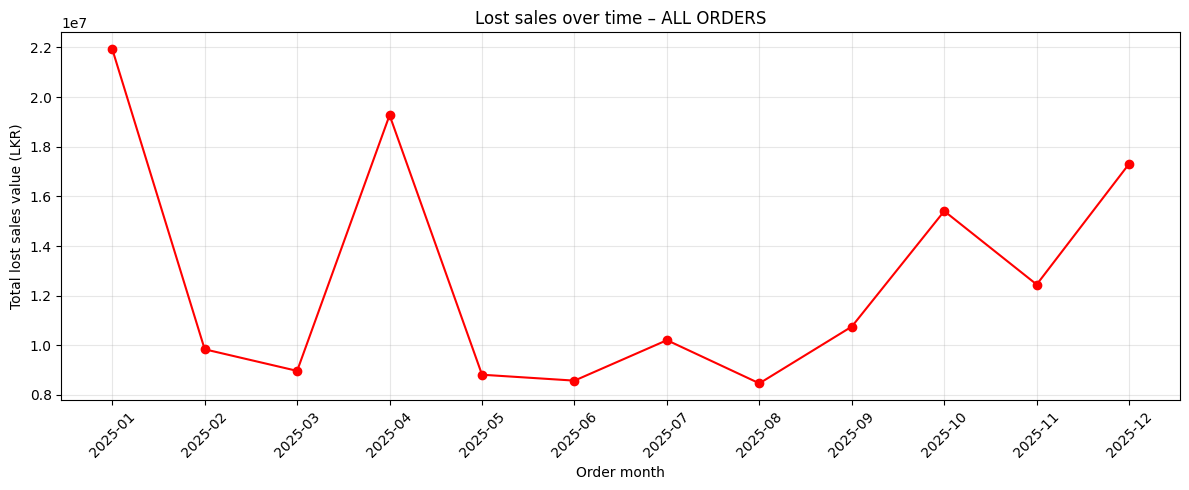

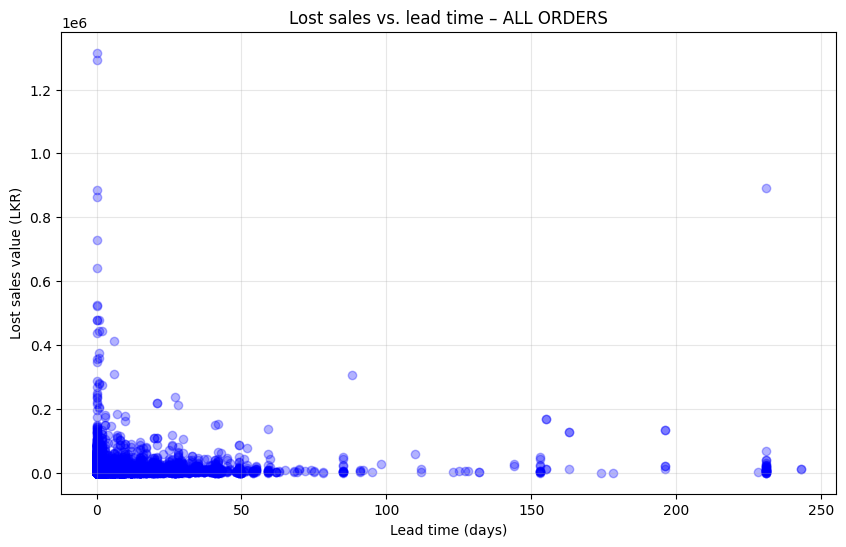


Lost Sales Analysis – NON‑CANCELLED ORDERS
Total lost sales value: 43,116,011.58 LKR
Average lost sales per order: 1,167.32 LKR
Orders with positive lost sales: 4743
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                             part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
   21C-E3440-01              ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           147       1427390.005         9710.14
    94702-00217    S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            60       1024596.000        17076.60
99000-22B63-046       SUZUKI CVT FLUID (GREEN II 4 L)                     Unknown             1        884400.000       884400.00
   2RB-14940-00                        DIAPHRAGM ASSY Ray ZR,Ray ZR Street Rallay           110        698389.510         6349.00
   B62-F5190-00                        GEAR UNIT ASSY Ray ZR,Ray ZR Street Rallay           105  

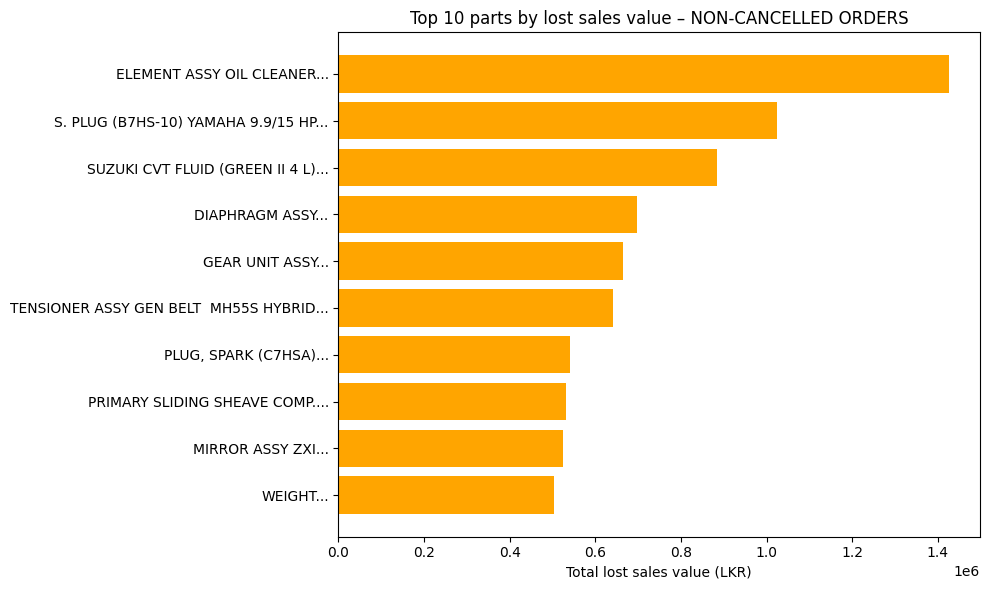


Top 10 customers by total lost sales value:
         Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
          Wijesinghe Motors           337      1.968298e+06     5840.646464
      Wasantha Motors Galle           521      1.740259e+06     3340.227497
           Green Auto Lanka             8      1.725015e+06   215626.848750
Jaffna Automobile (pvt) Ltd            34      1.264597e+06    37194.015294
             Modern  Motors           451      1.237237e+06     2743.320021
       Manju Service Center           514      1.225823e+06     2384.870142
       Nalinda Super Motors           206      9.411912e+05     4568.889265
               Union Motors           288      8.533336e+05     2962.963889
              Samagi Motors           462      8.075344e+05     1747.910031
         Mahesh Enterprises           215      7.139782e+05     3320.828768


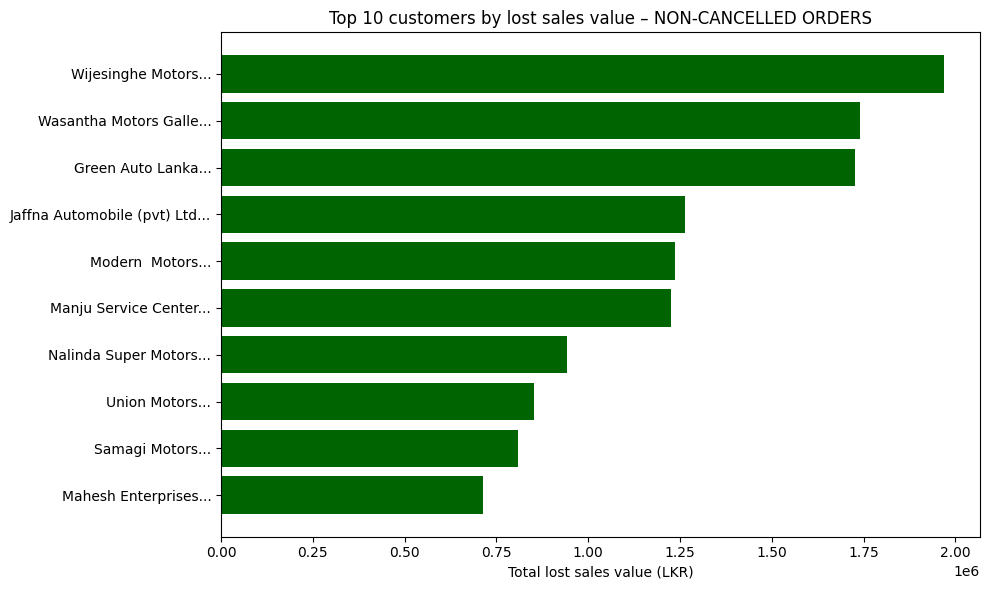


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ          7041      8.378154e+06     1189.909732
              FZ V.2          7041      8.378154e+06     1189.909732
               MT 15          7041      8.378154e+06     1189.909732
                 R15          7041      8.378154e+06     1189.909732
                 V.4          7041      8.378154e+06     1189.909732
              Ray ZR          4740      7.129667e+06     1504.149181
Ray ZR Street Rallay          4740      7.129667e+06     1504.149181
              COMMON           539      1.258901e+06     2335.622720


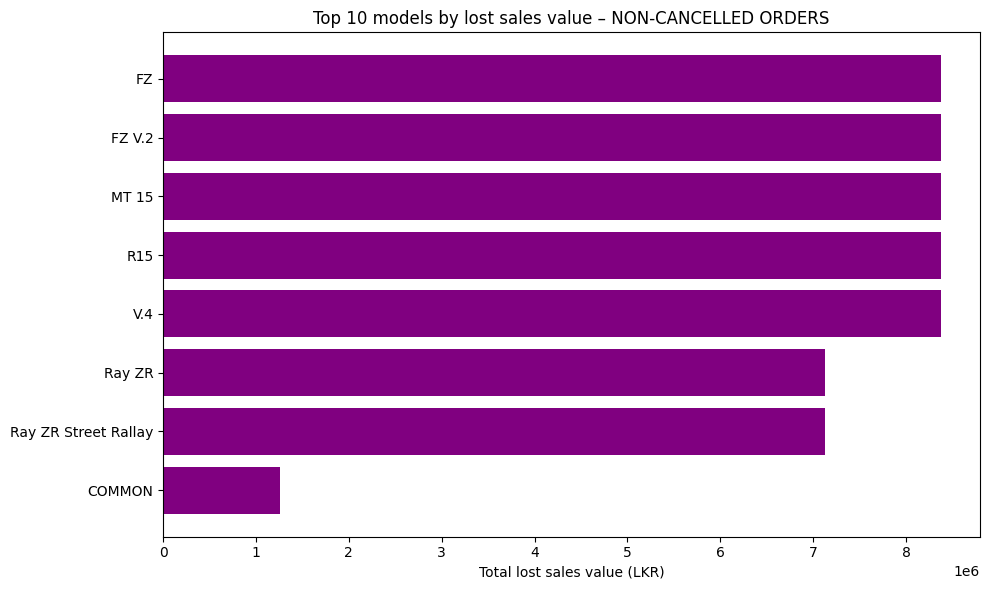

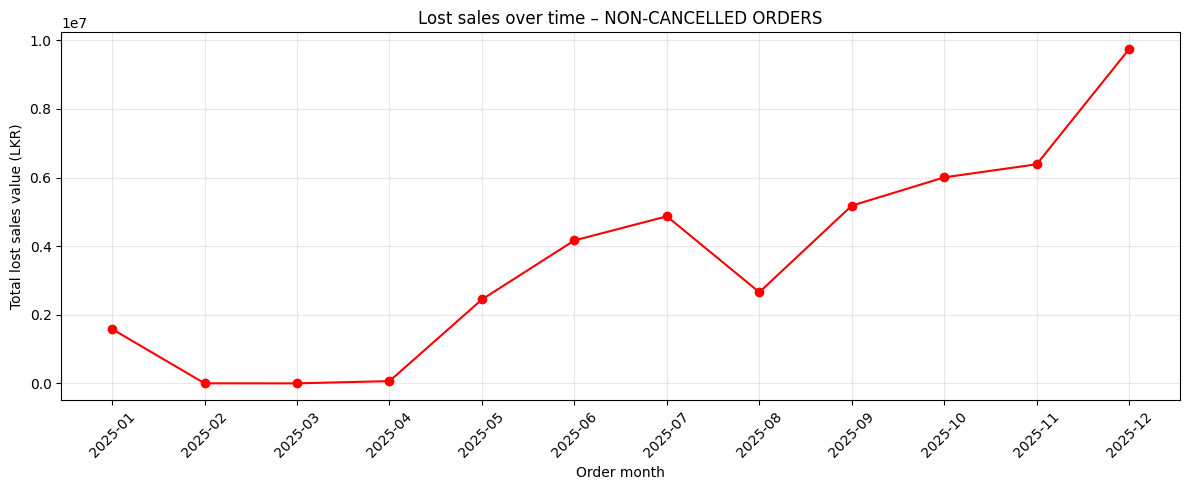

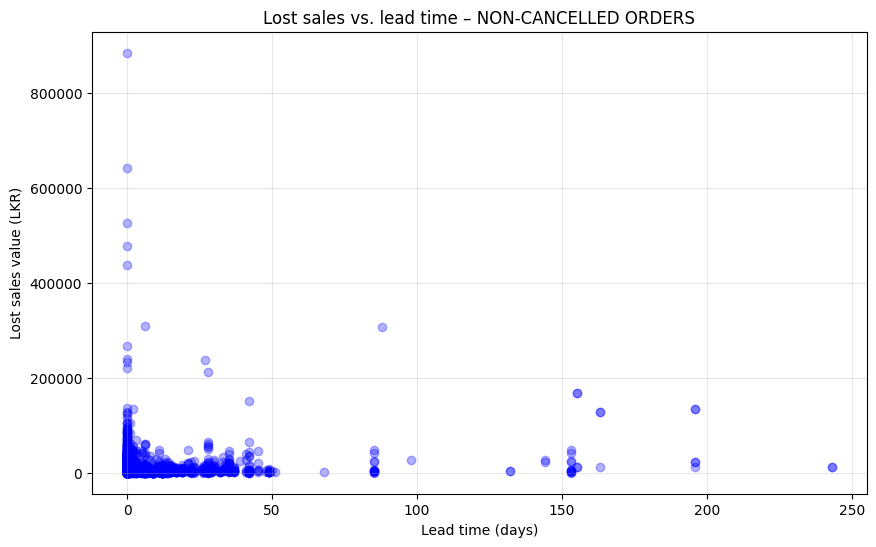


Lost Sales Analysis – CANCELLED ORDERS
Total lost sales value: 108,882,861.09 LKR
Average lost sales per order: 7,017.00 LKR
Orders with positive lost sales: 10917
Orders with over‑delivery (negative lost): 0

Top 10 parts by total lost sales value:
       Material                          part_desc                      models  total_orders  total_lost_sales  avg_lost_sales
1GC-WE661-10-00                CYLINDER PISTON KIT                     Unknown            18      2.434678e+06       135259.86
   4EB-23145-01                  OIL SEAL YAM FZ16   FZ V.2,MT 15,FZ,V.4, R15,            83      2.197847e+06        26480.08
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            20      2.189488e+06       109474.42
1GC-E4450-00-00 ELEMENT ASSY,AIR CLEANER YAM XC115                     Unknown           148      2.092670e+06        14139.66
      571902NAE                 YAMALUBE 10W40 YAM                     Unknown           105      2.008375e+06    

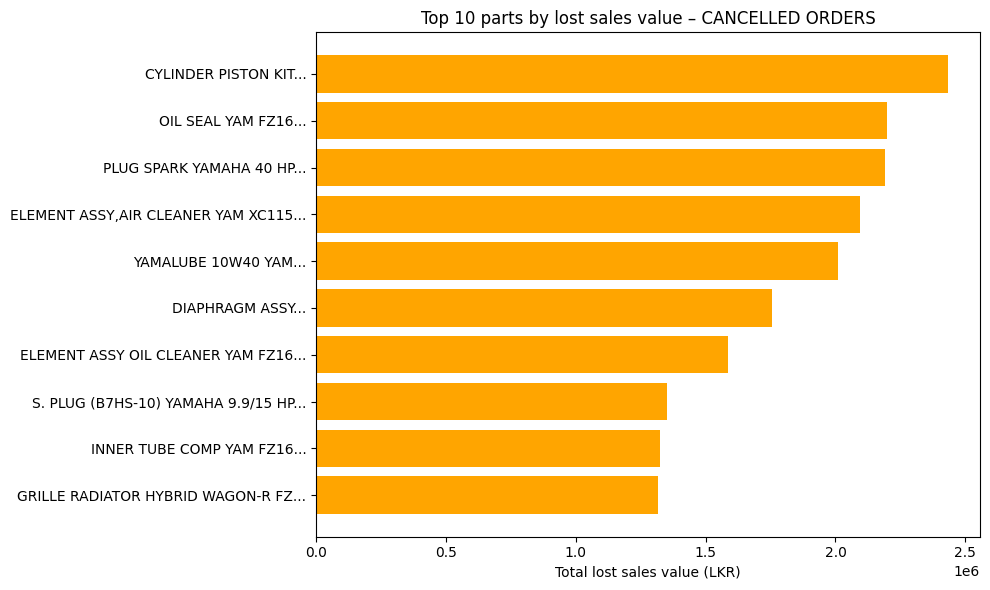


Top 10 customers by total lost sales value:
                   Sold-To Party Name  total_orders  total_lost_sales  avg_lost_sales
               Union Auto Enterprises          2046      8.419668e+06     4115.184855
Fernando Auto House (private) Limited            35      5.554906e+06   158711.610371
                      Azhakan Traders           138      3.775413e+06    27358.067126
             New Chilaw Yamaha Center           154      3.466406e+06    22509.132407
                    New Indika Motors           189      3.148180e+06    16657.039342
                           Chen Koong           287      2.369578e+06     8256.370650
                  Digital Electronics           310      2.243043e+06     7235.622676
                        Windom Motors           263      2.224881e+06     8459.624915
  Chandima Enterprises - Nikaweratiya           198      2.086999e+06    10540.400627
          Rathnasiri Motorcycle Works           268      1.957470e+06     7303.993681


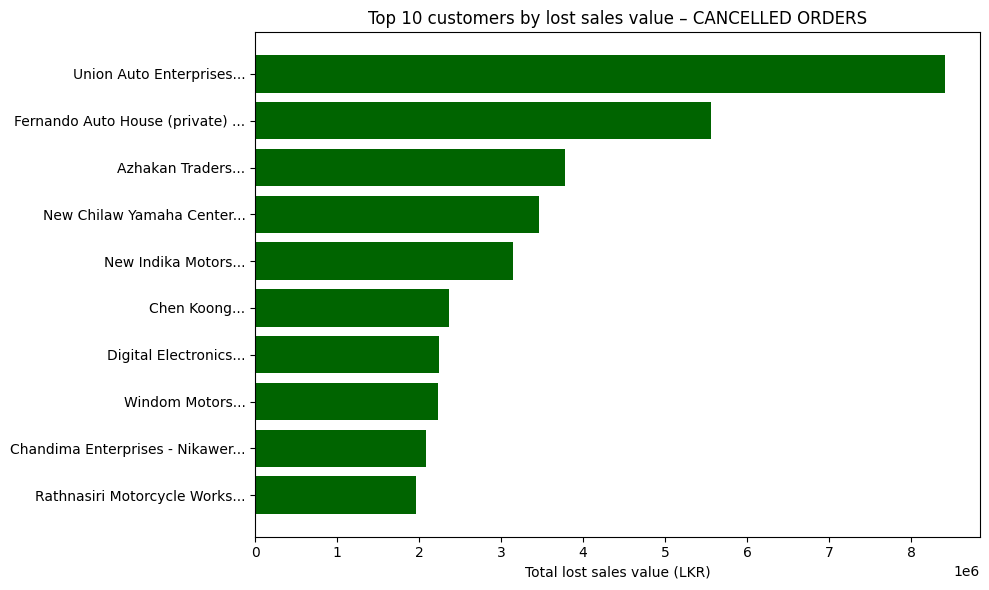


Top 10 models by total lost sales value:
              models  total_orders  total_lost_sales  avg_lost_sales
                  FZ          3329      1.997702e+07     6000.908445
              FZ V.2          3329      1.997702e+07     6000.908445
               MT 15          3329      1.997702e+07     6000.908445
                 R15          3329      1.997702e+07     6000.908445
                 V.4          3329      1.997702e+07     6000.908445
              Ray ZR          2331      1.100084e+07     4719.366684
Ray ZR Street Rallay          2331      1.100084e+07     4719.366684
              COMMON           317      2.243235e+06     7076.451429


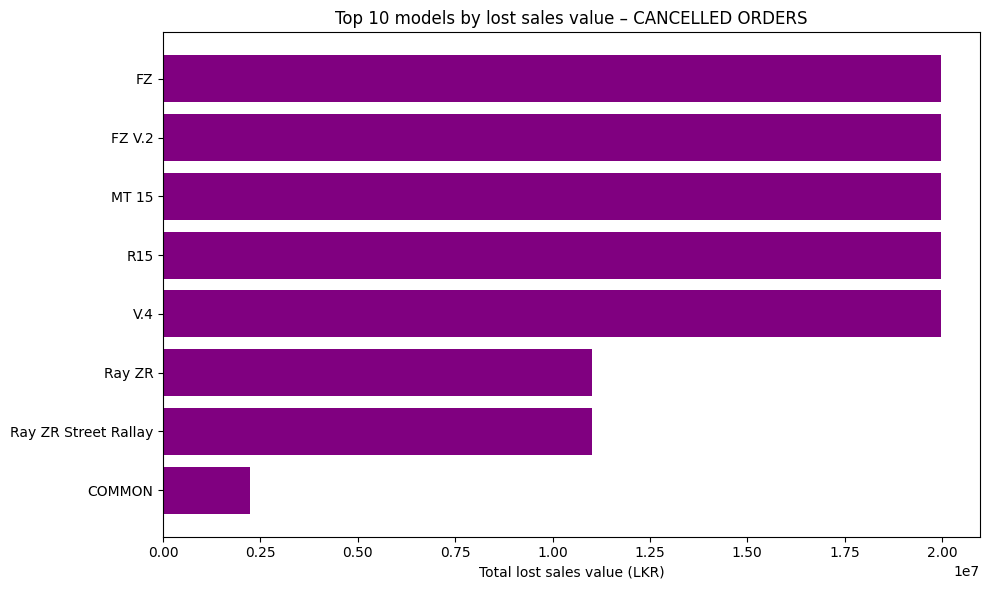

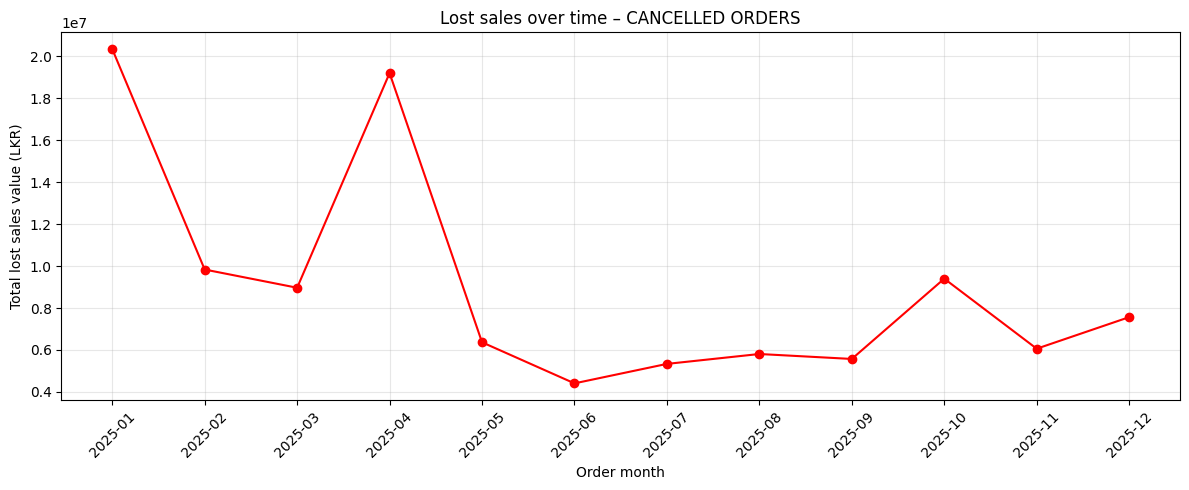

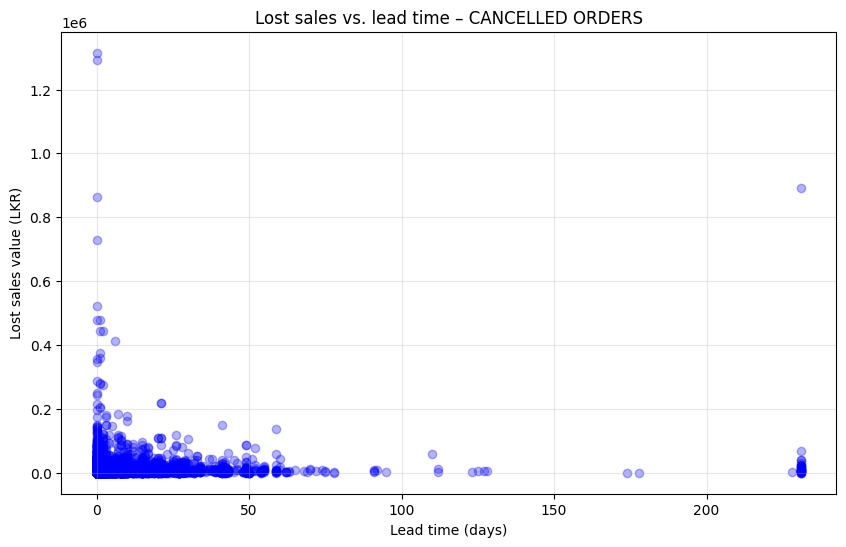

In [27]:
# ----- 1. Ensure merged_df exists (with model information) -----
# (If not already done, run this block)
ssop_df = pd.read_excel('SSOP.xlsx')
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Compatible models']].drop_duplicates(subset='PartNumber')

orders_df['Material'] = orders_df['Material'].astype(str).str.strip()
merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# ----- 2. Define analysis function -----
def analyze_lost_sales(df, group_name):
    print(f"\n{'='*60}")
    print(f"Lost Sales Analysis – {group_name}")
    print('='*60)

    # Avoid division by zero
    df = df.copy()
    df['Unit Price'] = df.apply(
        lambda row: row['Net Value (Item)'] / row['Order Quantity (Item)']
        if pd.notna(row['Net Value (Item)']) and pd.notna(row['Order Quantity (Item)']) and row['Order Quantity (Item)'] > 0
        else 0,
        axis=1
    )
    df['Lost Sales Value'] = df['Lost Qty'] * df['Unit Price']

    # Basic stats
    total_lost_sales = df['Lost Sales Value'].sum()
    avg_lost_sales_per_order = df['Lost Sales Value'].mean()
    orders_with_lost_sales = (df['Lost Sales Value'] > 0).sum()
    orders_with_negative_lost = (df['Lost Sales Value'] < 0).sum()   # over‑delivery

    print(f"Total lost sales value: {total_lost_sales:,.2f} LKR")
    print(f"Average lost sales per order: {avg_lost_sales_per_order:,.2f} LKR")
    print(f"Orders with positive lost sales: {orders_with_lost_sales}")
    print(f"Orders with over‑delivery (negative lost): {orders_with_negative_lost}")

    # ---- Part‑wise lost sales ----
    part_lost_sales = df.groupby('Material').agg(
        part_desc=('Material Description', 'first'),
        models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)
    part_lost_sales['avg_lost_sales'] = part_lost_sales['avg_lost_sales'].round(2)

    print("\nTop 10 parts by total lost sales value:")
    print(part_lost_sales.head(10).to_string(index=False))

    # Bar chart – top 10 parts
    top10_parts = part_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_parts)), top10_parts['total_lost_sales'].values, color='orange')
    plt.yticks(range(len(top10_parts)), top10_parts['part_desc'].str[:40] + '...')
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 parts by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Customer‑wise lost sales ----
    cust_lost_sales = df.groupby('Sold-To Party Name').agg(
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)

    print("\nTop 10 customers by total lost sales value:")
    print(cust_lost_sales.head(10).to_string(index=False))

    top10_cust = cust_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_cust)), top10_cust['total_lost_sales'].values, color='darkgreen')
    plt.yticks(range(len(top10_cust)), top10_cust['Sold-To Party Name'].str[:30] + '...')
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 customers by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Model‑wise lost sales (exploded) ----
    model_df = df.copy()
    model_df['models'] = model_df['Compatible models'].str.split(',')
    model_exploded = model_df.explode('models')
    model_exploded['models'] = model_exploded['models'].str.strip()
    model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

    model_lost_sales = model_exploded.groupby('models').agg(
        total_orders=('Lost Sales Value', 'count'),
        total_lost_sales=('Lost Sales Value', 'sum'),
        avg_lost_sales=('Lost Sales Value', 'mean')
    ).reset_index().sort_values('total_lost_sales', ascending=False)

    print("\nTop 10 models by total lost sales value:")
    print(model_lost_sales.head(10).to_string(index=False))

    top10_models = model_lost_sales.head(10)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(top10_models)), top10_models['total_lost_sales'].values, color='purple')
    plt.yticks(range(len(top10_models)), top10_models['models'])
    plt.xlabel('Total lost sales value (LKR)')
    plt.title(f'Top 10 models by lost sales value – {group_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ---- Time trend ----
    df['Order Month'] = df['Created On'].dt.to_period('M')
    monthly_lost_sales = df.groupby('Order Month')['Lost Sales Value'].sum().reset_index()
    monthly_lost_sales['Order Month'] = monthly_lost_sales['Order Month'].astype(str)

    plt.figure(figsize=(12,5))
    plt.plot(monthly_lost_sales['Order Month'], monthly_lost_sales['Lost Sales Value'], marker='o', color='red')
    plt.xlabel('Order month')
    plt.ylabel('Total lost sales value (LKR)')
    plt.title(f'Lost sales over time – {group_name}')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- Lost sales vs. lead time (positive loss only) ----
    pos_lost_sales = df[df['Lost Sales Value'] > 0].copy()
    if len(pos_lost_sales) > 0:
        plt.figure(figsize=(10,6))
        plt.scatter(pos_lost_sales['Lead Time'], pos_lost_sales['Lost Sales Value'], alpha=0.3, color='blue')
        plt.xlabel('Lead time (days)')
        plt.ylabel('Lost sales value (LKR)')
        plt.title(f'Lost sales vs. lead time – {group_name}')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No positive lost sales orders to plot.")

    return part_lost_sales, cust_lost_sales, model_lost_sales

# ----- 3. Run the analysis for all three groups -----
all_sales = analyze_lost_sales(merged_df, "ALL ORDERS")

non_cancelled = merged_df[merged_df['Is Cancelled'] == False].copy()
non_cancelled_sales = analyze_lost_sales(non_cancelled, "NON‑CANCELLED ORDERS")

cancelled = merged_df[merged_df['Is Cancelled'] == True].copy()
cancelled_sales = analyze_lost_sales(cancelled, "CANCELLED ORDERS")

# ----- 4. (Optional) Save results to CSV -----
#all_sales[0].to_csv('lost_sales_all_parts.csv', index=False)
#all_sales[1].to_csv('lost_sales_all_customers.csv', index=False)
#all_sales[2].to_csv('lost_sales_all_models.csv', index=False)

#non_cancelled_sales[0].to_csv('lost_sales_non_cancelled_parts.csv', index=False)
#non_cancelled_sales[1].to_csv('lost_sales_non_cancelled_customers.csv', index=False)
#non_cancelled_sales[2].to_csv('lost_sales_non_cancelled_models.csv', index=False)

#cancelled_sales[0].to_csv('lost_sales_cancelled_parts.csv', index=False)
#cancelled_sales[1].to_csv('lost_sales_cancelled_customers.csv', index=False)
#cancelled_sales[2].to_csv('lost_sales_cancelled_models.csv', index=False)

In [28]:
# ----- 0. Ensure we have the non‑cancelled subset -----
# (Assuming orders_df is already loaded and 'Is Cancelled' exists)
non_cancelled = orders_df[orders_df['Is Cancelled'] == False].copy()

# ----- 1. Prepare part‑level data -----
# Keep only rows with valid part number and sales value
part_data = non_cancelled[non_cancelled['Material'].notna()].copy()

# Calculate total sales value per part
part_sales = part_data.groupby('Material').agg(
    part_desc=('Material Description', 'first'),
    total_sales_value=('Net Value (Item)', 'sum'),
    total_orders=('Net Value (Item)', 'count'),
    total_qty=('Order Quantity (Item)', 'sum'),
    mean_qty=('Order Quantity (Item)', 'mean'),
    std_qty=('Order Quantity (Item)', 'std')
).reset_index()

# Replace NaN std (single order) with 0
part_sales['std_qty'] = part_sales['std_qty'].fillna(0)

# Coefficient of variation (avoid division by zero)
part_sales['cv'] = part_sales.apply(
    lambda row: row['std_qty'] / row['mean_qty'] if row['mean_qty'] > 0 else 0,
    axis=1
)

# ----- 2. ABC classification (by total sales value) -----
# Sort by total_sales_value descending
part_sales = part_sales.sort_values('total_sales_value', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage of total sales
total_sales_all = part_sales['total_sales_value'].sum()
part_sales['cum_pct'] = part_sales['total_sales_value'].cumsum() / total_sales_all * 100

# Assign classes (typical thresholds: A: 0-70%, B: 70-90%, C: 90-100%)
def abc_class(cum_pct):
    if cum_pct <= 70:
        return 'A'
    elif cum_pct <= 90:
        return 'B'
    else:
        return 'C'

part_sales['ABC'] = part_sales['cum_pct'].apply(abc_class)

# ----- 3. XYZ classification (by coefficient of variation) -----
def xyz_class(cv):
    if cv < 0.5:
        return 'X'
    elif cv < 1.0:
        return 'Y'
    else:
        return 'Z'

part_sales['XYZ'] = part_sales['cv'].apply(xyz_class)

# ----- 4. Combine with model information (from SSOP) -----
# Load SSOP to get compatible models
ssop_df = pd.read_excel('SSOP.xlsx')
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Compatible models']].drop_duplicates(subset='PartNumber')

# Merge
part_sales = part_sales.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')
part_sales.rename(columns={'Compatible models': 'models'}, inplace=True)

# ----- 5. Final output -----
# Select and reorder columns for clarity
result = part_sales[[
    'Material', 'part_desc', 'models',
    'total_sales_value', 'total_orders', 'total_qty',
    'mean_qty', 'std_qty', 'cv', 'ABC', 'XYZ'
]]

print("ABC‑XYZ classification for non‑cancelled parts:")
print(result.head(20).to_string())

# Save to CSV
#result.to_csv('abc_xyz_classification_non_cancelled.csv', index=False)

ABC‑XYZ classification for non‑cancelled parts:
           Material                           part_desc                       models  total_sales_value  total_orders  total_qty     mean_qty      std_qty        cv ABC XYZ
0         571901NAE                  YAMALUBE 20W40 YAM                          NaN        78556397.15           749      48264    64.437917    71.526110  1.110000   A   Z
1         571902NAE                  YAMALUBE 10W40 YAM                          NaN        57233243.29           583      33971    58.269297    78.558826  1.348203   A   Z
2         571837NAE               YAMALUBE MB 10W40 YAM                          NaN        27307868.73           405      14923    36.846914    40.265656  1.092782   A   Z
3       94702-00217  S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                          NaN        24963593.40            60      53408   890.133333  1544.556669  1.735197   A   Z
4      KARBAT012V5A                      KARATE BATTERY                          NaN   

In [33]:
import pandas as pd
import numpy as np

# ----- Ensure we have the non‑cancelled DataFrame -----
non_cancelled = merged_df[merged_df['Is Cancelled'] == False].copy()

# Aggregate
part_agg = non_cancelled.groupby('Material').agg(
    part_desc=('Material Description', 'first'),
    total_qty=('Order Quantity (Item)', 'sum'),
    total_sales=('Net Value (Item)', 'sum'),
    order_count=('Order Quantity (Item)', 'count'),
    avg_qty=('Order Quantity (Item)', 'mean'),
    std_qty=('Order Quantity (Item)', 'std')
).reset_index()

# Compute CV; handle parts with only one order (std NaN) -> CV = 0 (low variability)
part_agg['cv'] = part_agg.apply(
    lambda row: row['std_qty'] / row['avg_qty'] if pd.notna(row['std_qty']) and row['avg_qty'] > 0 else 0,
    axis=1
)

# Check first rows
print(part_agg.head())

# Sort by total quantity descending
part_abc = part_agg.sort_values('total_qty', ascending=False).copy()

# Compute cumulative percentage
part_abc['cum_qty'] = part_abc['total_qty'].cumsum()
total_qty_sum = part_abc['total_qty'].sum()
part_abc['cum_pct'] = part_abc['cum_qty'] / total_qty_sum * 100

# Assign ABC classes
# Typical thresholds: A = top 80% of cumulative quantity, B = next 15%, C = last 5%
def assign_abc(cum_pct):
    if cum_pct <= 80:
        return 'A'
    elif cum_pct <= 95:
        return 'B'
    else:
        return 'C'

part_abc['abc_class'] = part_abc['cum_pct'].apply(assign_abc)

print("\nABC Classification (based on total quantity):")
print(part_abc[['Material', 'part_desc', 'total_qty', 'cum_pct', 'abc_class']].head(10))

def assign_xyz(cv):
    if cv < 0.5:
        return 'X'
    elif cv < 1.0:
        return 'Y'
    else:
        return 'Z'

part_agg['xyz_class'] = part_agg['cv'].apply(assign_xyz)

print("\nXYZ Classification (based on CV):")
print(part_agg[['Material', 'part_desc', 'avg_qty', 'std_qty', 'cv', 'xyz_class']].head(10))

# Get percentiles
p80 = part_agg['order_count'].quantile(0.8)
p50 = part_agg['order_count'].quantile(0.5)

def assign_fsn(cnt):
    if cnt >= p80:
        return 'F'
    elif cnt >= p50:
        return 'S'
    else:
        return 'N'

part_agg['fsn_class'] = part_agg['order_count'].apply(assign_fsn)

print("\nFSN Classification (based on order count):")
print(part_agg[['Material', 'part_desc', 'order_count', 'fsn_class']].head(10))

# Merge the ABC column from part_abc into part_agg
final = part_agg.merge(part_abc[['Material', 'abc_class']], on='Material', how='left')

# Reorder columns
final = final[['Material', 'part_desc', 'total_qty', 'total_sales', 'order_count',
               'avg_qty', 'std_qty', 'cv', 'abc_class', 'xyz_class', 'fsn_class']]

print("\nFinal ABC‑XYZ‑FSN Classification (first 10 rows):")
print(final.head(10).to_string(index=False))

# Save to CSV
final.to_csv('abc_xyz_fsn_classification.csv', index=False)

print("\nABC class counts:")
print(final['abc_class'].value_counts().sort_index())

print("\nXYZ class counts:")
print(final['xyz_class'].value_counts().sort_index())

print("\nFSN class counts:")
print(final['fsn_class'].value_counts().sort_index())

      Material                      part_desc  total_qty  total_sales  \
0  01550M0835A  BOLT,INTAKE MANIFOLD M A-STAR         14       140.01   
1  09103M10028          BOLT (10X20) M 800 MC         21       209.92   
2  09111M08090         BOLT CONT SHAFT M ALTO         10       100.06   
3  09117M12006             BOLT CALIPER M 800          3        30.00   
4  09140M12040                WHEEL NUT M 410        200      8201.76   

   order_count  avg_qty  std_qty   cv  
0            1     14.0      NaN  0.0  
1            1     21.0      NaN  0.0  
2            1     10.0      NaN  0.0  
3            1      3.0      NaN  0.0  
4            4     50.0      0.0  0.0  

ABC Classification (based on total quantity):
             Material                           part_desc  total_qty  \
3251      94702-00217  S. PLUG (B7HS-10) YAMAHA 9.9/15 HP      53408   
2016        571901NAE                  YAMALUBE 20W40 YAM      48264   
2017        571902NAE                  YAMALUBE 10W40 YAM 

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ----- Load the classification data -----
# (Assuming final is already created from the previous step)
# If not, rerun the ABC-XYZ-FSN code first.

# Select features
feature_cols = ['total_qty', 'total_sales', 'order_count', 'avg_qty', 'std_qty', 'cv']
X = final[feature_cols].copy()

# Handle any missing values (should not happen, but just in case)
X = X.fillna(0)

# Targets
y_abc = final['abc_class']
y_xyz = final['xyz_class']
y_fsn = final['fsn_class']

# Split for ABC
X_train, X_test, y_abc_train, y_abc_test = train_test_split(
    X, y_abc, test_size=0.3, random_state=42, stratify=y_abc
)

# For XYZ and FSN we use the same X split (targets differ, but we can reuse X_train/X_test)
_, _, y_xyz_train, y_xyz_test = train_test_split(
    X, y_xyz, test_size=0.3, random_state=42, stratify=y_xyz
)

_, _, y_fsn_train, y_fsn_test = train_test_split(
    X, y_fsn, test_size=0.3, random_state=42, stratify=y_fsn
)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, target_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name} – {target_name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {'model': model_name, 'target': target_name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1}

rf_abc = RandomForestClassifier(n_estimators=100, random_state=42)
res_rf_abc = evaluate_model(rf_abc, X_train, X_test, y_abc_train, y_abc_test,
                            "Random Forest", "ABC")

rf_xyz = RandomForestClassifier(n_estimators=100, random_state=42)
res_rf_xyz = evaluate_model(rf_xyz, X_train, X_test, y_xyz_train, y_xyz_test,
                            "Random Forest", "XYZ")

rf_fsn = RandomForestClassifier(n_estimators=100, random_state=42)
res_rf_fsn = evaluate_model(rf_fsn, X_train, X_test, y_fsn_train, y_fsn_test,
                            "Random Forest", "FSN")

xgb_abc = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
res_xgb_abc = evaluate_model(xgb_abc, X_train, X_test, y_abc_train, y_abc_test,
                             "XGBoost", "ABC")

xgb_xyz = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
res_xgb_xyz = evaluate_model(xgb_xyz, X_train, X_test, y_xyz_train, y_xyz_test,
                             "XGBoost", "XYZ")

xgb_fsn = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
res_xgb_fsn = evaluate_model(xgb_fsn, X_train, X_test, y_fsn_train, y_fsn_test,
                             "XGBoost", "FSN")

results = pd.DataFrame([
    res_rf_abc, res_rf_xyz, res_rf_fsn,
    res_xgb_abc, res_xgb_xyz, res_xgb_fsn
])

print("\n=== Model Comparison ===")
print(results.to_string(index=False))

# For Random Forest (ABC)
import matplotlib.pyplot as plt

importances = rf_abc.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importances – Random Forest (ABC)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


Random Forest – ABC
Accuracy:  0.9971
Precision: 0.9971
Recall:    0.9971
F1-score:  0.9971

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        51
           B       1.00      0.99      0.99       272
           C       1.00      1.00      1.00      1064

    accuracy                           1.00      1387
   macro avg       1.00      1.00      1.00      1387
weighted avg       1.00      1.00      1.00      1387


Random Forest – XYZ
Accuracy:  0.6172
Precision: 0.5668
Recall:    0.6172
F1-score:  0.5871

Classification Report:
              precision    recall  f1-score   support

           X       0.71      0.81      0.76       981
           Y       0.26      0.17      0.20       316
           Z       0.11      0.07      0.08        90

    accuracy                           0.62      1387
   macro avg       0.36      0.35      0.35      1387
weighted avg       0.57      0.62      0.59      1387


Ran

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['A' 'B' 'C']